# `Testando a influência do El nino e da Zona de Convergência do Atlântico Sul na ocorrência de precipitações extremas no estado de Minas Gerais.`

---



In [2]:
# inicialmente vamos importar as bibliotecas que serão utilizadas durante a análise
!pip install geobr geopandas

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import genextreme, chi2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.1.1
    Uninstalling lxml-6.1.1:
      Successfully uninstalled lxml-6.1.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3


In [3]:
# Essa linda de código é importante pois ela conecta o notebook com os arquivos do drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Em outra página ja havia rodado um comando que calculou as máximas diárias de cada pixel associado a malha de dados de Xavier *et al* bem como os dados referentes as ocorrências do El nino. Por isso, a próximo código consegue pular etapas, ja indo diretamente para o banco de dados conjunto das máximas diárias anuais de precipitação, juntamente com a ocorrência do El nino.

---



In [4]:
import xarray as xr

# Carrega o arquivo mastigado instantaneamente
caminho_input = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/br_maximas_anuais_oni_1961_2025.nc"
ds_maximas_anuais = xr.open_dataset(caminho_input)

print("Cubo de dados pronto para a modelagem estatística!")
print(ds_maximas_anuais)

Cubo de dados pronto para a modelagem estatística!
<xarray.Dataset> Size: 80MB
Dimensions:    (ano: 65, latitude: 393, longitude: 391)
Coordinates:
  * ano        (ano) int64 520B 1961 1962 1963 1964 1965 ... 2022 2023 2024 2025
  * latitude   (latitude) float32 2kB -33.85 -33.75 -33.65 ... 5.15 5.25 5.35
  * longitude  (longitude) float32 2kB -73.85 -73.75 -73.65 ... -34.95 -34.85
Data variables:
    pr         (ano, latitude, longitude) float64 80MB ...


In [5]:
import pandas as pd
import numpy as np

print("Buscando e processando o índice ONI da NOAA...")

url_oni = "https://psl.noaa.gov/data/correlation/oni.data"

# CORREÇÃO: Usando read_csv com sep=r'\s+' para forçar a divisão por espaços em branco
df_oni_bruto = pd.read_csv(url_oni, sep=r'\s+', skiprows=1, skipfooter=8, header=None, engine='python')

# Agora temos certeza absoluta de que há 13 colunas
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
df_oni_bruto.columns = ['ano'] + meses

# Substitui o valor nulo do arquivo da NOAA (-99.90) pelo NaN padrão do Python
df_oni_bruto = df_oni_bruto.replace(-99.90, np.nan)

# O pulo do gato: Desloca o mês de Dezembro para casar com o Verão do ano seguinte
df_oni_bruto['Dez_anterior'] = df_oni_bruto['Dez'].shift(1)
df_oni_bruto['ONI_Verao'] = df_oni_bruto[['Dez_anterior', 'Jan', 'Fev']].mean(axis=1)

# Cria a tabela final de covariável
df_covariavel_enso = df_oni_bruto[['ano', 'ONI_Verao']].dropna().copy()

# Garantindo que a coluna de ano seja um número inteiro para facilitar o cruzamento depois
df_covariavel_enso['ano'] = df_covariavel_enso['ano'].astype(int)

print(f"Série do El Niño calibrada de {df_covariavel_enso['ano'].min()} a {df_covariavel_enso['ano'].max()}!")

Buscando e processando o índice ONI da NOAA...
Série do El Niño calibrada de 1950 a 2026!


Com os dados carregados, no próximo código serão testadas diferentes GEVS, assumiremos aqui que o clima é não linear ao longo dos anos, principalmente se tratando de Teoria de Valores Extremos. Serão testados 4 modelos; O modelo estacionário, que considera que nenhum parâmetro varia com o tempo. O modelo mu1 que considera que o parâmetro mu varia linearmente em função da variação da temperatura do oceano "El Nino", o parâmetro assume a seguinte forma $\mu(t) = \mu_0 + \mu_1 \cdot \text{ONI}_t$, em que VTO representa a variação na temperatura do Oceano. O terceiro modelo a ser testado é o modelos que apresenta uma variação em função do parâmetro sigma, o parâmetro assume a forma $\sigma(t) = \exp(\sigma_0 + \sigma_1 \cdot \text{ONI}_t)$. Por fim o modelo mais flexível, é representado por uma variação simultanea entre mu e sigma

\begin{align}
\mu(t) &= \mu_0 + \mu_1 \cdot \text{ONI}_t\\
\sigma(t) &= \exp(\sigma_0 + \sigma_1 )
\end{align}

Os parâmetros forame stimados via método da máxima verossimilhança, como as equações não possuem solução analítica, métodos interativos foram utilizados para chegar nas estimativas. Os melhores modelos foram selecionados via critério AIC.

---






1. Abrindo o arquivo global de OLR (Lazy Loading)...
2. Fatiando as coordenadas espaciais de Minas Gerais...
3. Calculando a média diária de radiação sobre o estado...
4. Construindo o Índice ZCAS (Limiar: OLR < 220 W/m² no Verão)...

 -> Extração concluída com sucesso! Visualizando os dados gerados:


,ano,dias_ativos_zcas
28,2019.0,43
29,2020.0,53
30,2021.0,42
31,2022.0,48
32,2023.0,60
33,2024.0,41
34,2025.0,44
35,2026.0,54


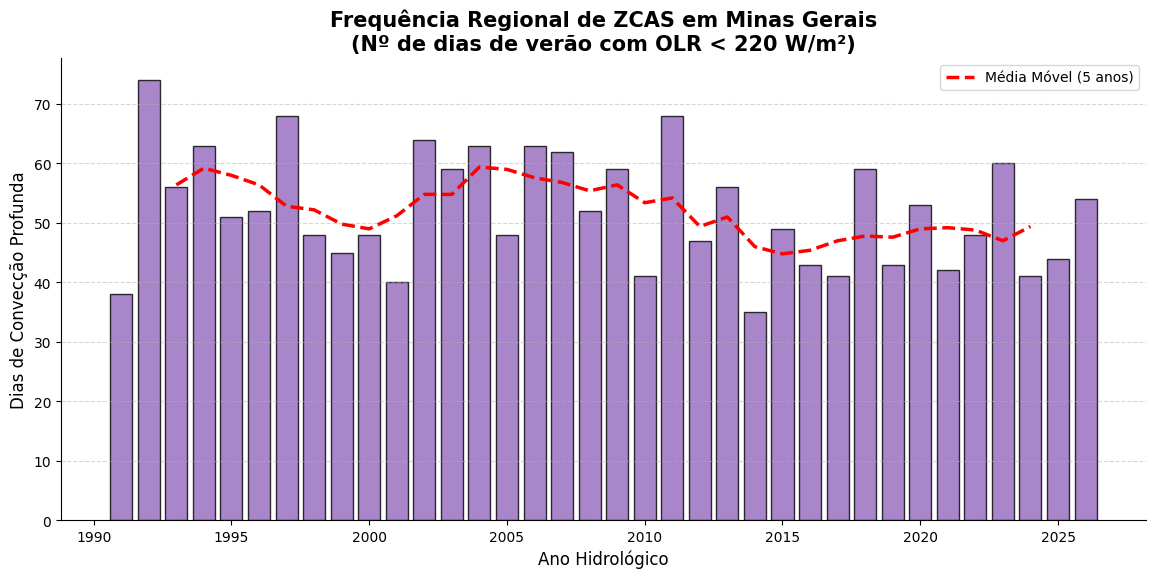

In [6]:
## Banco de dados referente a ZCAS
# ==============================================================================
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("1. Abrindo o arquivo global de OLR (Lazy Loading)...")
# ATENÇÃO: Confirme se o nome do arquivo baixado é exatamente este no seu Drive
caminho_olr = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/olr.cbo-1deg.day.mean.nc"

# O xarray abre o dataset de forma inteligente, mapeando os dados sem jogar tudo na RAM
ds_olr = xr.open_dataset(caminho_olr)

print("2. Fatiando as coordenadas espaciais de Minas Gerais...")
# O PULO DO GATO: A NOAA usa longitudes de 0 a 360.
# MG vai de aprox -51.5 a -39.5, o que na escala deles equivale a 308.5 a 320.5
lon_min, lon_max = 360 - 51.5, 360 - 39.5
lat_min, lat_max = -23.0, -14.0

# Ordenamos as coordenadas primeiro para evitar que o comando slice dê erro
ds_olr = ds_olr.sortby(['lat', 'lon'])
ds_mg_olr = ds_olr.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

print("3. Calculando a média diária de radiação sobre o estado...")
# Tira a média espacial da caixa para encontrar a assinatura geral sobre o estado
# Pegamos dinamicamente o nome da variável de dados (geralmente 'olr' ou 'rlut')
var_name = list(ds_mg_olr.data_vars)[0]
serie_diaria_mg = ds_mg_olr[var_name].mean(dim=['lat', 'lon']).to_dataframe()

serie_diaria_mg['ano'] = serie_diaria_mg.index.year
serie_diaria_mg['mes'] = serie_diaria_mg.index.month

print("4. Construindo o Índice ZCAS (Limiar: OLR < 220 W/m² no Verão)...")
# Filtra apenas a janela clássica de atuação convectiva: Nov, Dez, Jan, Fev, Mar
verao = serie_diaria_mg[serie_diaria_mg['mes'].isin([11, 12, 1, 2, 3])].copy()

# Marca os dias que romperam o limiar crítico
limiar_zcas = 220.0
verao['dia_zcas'] = (verao[var_name] < limiar_zcas).astype(int)

# AJUSTE METODOLÓGICO FINO: O Ano Hidrológico
# Dezembro de 2010 e Janeiro de 2011 pertencem ao mesmo verão!
# Atribuímos os meses 11 e 12 ao "ano" seguinte para cruzar certinho com a sua máxima anual.
verao['ano_hidrologico'] = verao.apply(lambda row: row['ano'] + 1 if row['mes'] >= 11 else row['ano'], axis=1)

# Agrupa e conta o total de dias de ZCAS por ano hidrológico
indice_zcas = verao.groupby('ano_hidrologico')['dia_zcas'].sum().reset_index()
indice_zcas.rename(columns={'ano_hidrologico': 'ano', 'dia_zcas': 'dias_ativos_zcas'}, inplace=True)

print("\n -> Extração concluída com sucesso! Visualizando os dados gerados:")
display(indice_zcas.tail(8))

# ------------------------------------------------------------------------------
# PLOTAGEM DO COMPORTAMENTO HISTÓRICO DA ZCAS
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.bar(indice_zcas['ano'], indice_zcas['dias_ativos_zcas'], color='#9467bd', edgecolor='black', alpha=0.8)

plt.title("Frequência Regional de ZCAS em Minas Gerais\n(Nº de dias de verão com OLR < 220 W/m²)", fontsize=15, fontweight='bold')
plt.xlabel("Ano Hidrológico", fontsize=12)
plt.ylabel("Dias de Convecção Profunda", fontsize=12)

# Adiciona uma linha de tendência móvel (Média de 5 anos) para ver os ciclos
plt.plot(indice_zcas['ano'], indice_zcas['dias_ativos_zcas'].rolling(5, center=True).mean(),
         color='red', linewidth=2.5, linestyle='--', label='Média Móvel (5 anos)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"
# Exportando o índice para facilitar usos futuros (opcional)
indice_zcas.to_csv(caminho_pasta + "indice_zcas_mg.csv", index=False)

In [7]:
import numpy as np
from scipy.signal import periodogram
import matplotlib.pyplot as plt

def calcular_periodo_zcas(df_zcas):
    """
    Aplica análise espectral para encontrar a frequência natural da ZCAS.
    """
    serie_zcas = df_zcas['dias_ativos_zcas'].values

    # Remove a média para o pico na frequência zero não esmagar as outras
    serie_centrada = serie_zcas - np.mean(serie_zcas)

    # Calcula o Periodograma
    frequencias, densidade = periodogram(serie_centrada)

    # Ignora o primeiro valor (f=0)
    f_validas = frequencias[1:]
    d_validas = densidade[1:]

    # Encontra a frequência que concentra a maior variância do fenômeno
    f_max = f_validas[np.argmax(d_validas)]
    periodo_dominante = 1 / f_max

    print(f"🔎 Análise Espectral Concluída!")
    print(f" -> O ciclo dominante da ZCAS encontrado foi de: {periodo_dominante:.2f} anos")

    return periodo_dominante

# Você roda isso UMA vez antes do loop dos pixels:
# periodo_zcas = calcular_periodo_zcas(indice_zcas)

In [13]:
from scipy.optimize import minimize
from scipy.stats import genextreme

def ajustar_gev_zcas_3_modelos(series_chuva, vetor_zcas, vetor_anos, periodo_t):
    """
    Compara: M0 (Estacionário), M1 (Linear em ZCAS) e M2 (Cíclico em T).
    Retorna: [mu0, mu1_ou_amplitude, sigma, xi, AIC, id_modelo]
    """
    validos = ~np.isnan(series_chuva) & ~np.isnan(vetor_zcas) & ~np.isnan(vetor_anos)
    y = series_chuva[validos]
    z = vetor_zcas[validos]  # O índice ZCAS daquele ano
    t_anos = vetor_anos[validos]

    if len(y) < 30:
        return [np.nan] * 6

    # Cria o eixo de tempo pro Modelo Cíclico
    t = t_anos - np.min(t_anos)
    cos_t = np.cos(2 * np.pi * t / periodo_t)
    sin_t = np.sin(2 * np.pi * t / periodo_t)

    resultados_aic = {}
    parametros = {}

    # =================================================================
    # M0: ESTACIONÁRIO (3 Parâmetros)
    # =================================================================
    def nll_m0(p):
        mu, sigma, xi = p
        if sigma <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=mu, scale=sigma))

    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    if res0.success:
        resultados_aic[0] = 2 * 3 + 2 * res0.fun
        parametros[0] = [res0.x[0], 0, res0.x[1], res0.x[2]]

    # =================================================================
    # M1: LINEAR COM A ZCAS (4 Parâmetros)
    # mu(t) = mu_0 + mu_1 * ZCAS(t)
    # =================================================================
    def nll_m1(p):
        mu0, mu1, sigma, xi = p
        if sigma <= 0: return 1e10
        loc_t = mu0 + mu1 * z
        return -np.sum(genextreme.logpdf(y, -xi, loc=loc_t, scale=sigma))

    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res1.success:
        resultados_aic[1] = 2 * 4 + 2 * res1.fun
        parametros[1] = [res1.x[0], res1.x[1], res1.x[2], res1.x[3]]

    # =================================================================
    # M2: CÍCLICO BASEADO NA FREQUÊNCIA DA ZCAS (5 Parâmetros)
    # mu(t) = mu_0 + beta_c * cos(...) + beta_s * sin(...)
    # =================================================================
    def nll_m2(p):
        mu0, mu_c, mu_s, sigma, xi = p
        if sigma <= 0: return 1e10
        loc_t = mu0 + mu_c * cos_t + mu_s * sin_t
        return -np.sum(genextreme.logpdf(y, -xi, loc=loc_t, scale=sigma))

    res2 = minimize(nll_m2, [res0.x[0], 0, 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res2.success:
        resultados_aic[2] = 2 * 5 + 2 * res2.fun
        # Transforma os coeficientes harmônicos na Amplitude total do ciclo
        amplitude = np.sqrt(res2.x[1]**2 + res2.x[2]**2)
        parametros[2] = [res2.x[0], amplitude, res2.x[3], res2.x[4]]

    # =================================================================
    # SELEÇÃO DO VENCEDOR (AIC)
    # =================================================================
    if not resultados_aic:
        return [np.nan] * 6

    melhor_modelo = min(resultados_aic, key=resultados_aic.get)
    menor_aic = resultados_aic[melhor_modelo]

    # Retorna o vetor formatado: [mu0, mu1_ou_Amp, sigma, xi, AIC, ID_Modelo]
    return parametros[melhor_modelo] + [menor_aic, melhor_modelo]

In [ ]:
# Ajuste da função que calcula as GEVS
from scipy.optimize import minimize
from scipy.stats import genextreme
import numpy as np

def ajustar_gev_4_modelos(series_chuva, series_oni):
    """
    Ajusta as 4 configurações da GEV e seleciona a melhor via AIC.
    """
    validos = ~np.isnan(series_chuva) & ~np.isnan(series_oni)
    y = series_chuva[validos]
    x = series_oni[validos]

    if len(y) < 30:
        return [np.nan] * 9 # Retorna NaNs se não houver dados suficientes

    resultados_aic = {}
    parametros_estimados = {}

    # --------------------------------------------------------------------------
    # MODELO 0: ESTACIONÁRIO (3 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m0(p):
        mu, sigma, xi = p
        if sigma <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=mu, scale=sigma))

    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    if res0.success:
        resultados_aic[0] = 2 * 3 + 2 * res0.fun # AIC = 2k - 2ln(L)
        parametros_estimados[0] = [res0.x[0], 0, res0.x[1], 0, res0.x[2]]

    # --------------------------------------------------------------------------
    # MODELO 1: NÃO-ESTACIONÁRIO EM MU (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m1(p):
        mu0, mu1, sigma, xi = p
        if sigma <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=(mu0 + mu1 * x), scale=sigma))

    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res1.success:
        resultados_aic[1] = 2 * 4 + 2 * res1.fun
        parametros_estimados[1] = [res1.x[0], res1.x[1], res1.x[2], 0, res1.x[3]]

    # --------------------------------------------------------------------------
    # MODELO 2: NÃO-ESTACIONÁRIO EM SIGMA (4 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m2(p):
        mu, sigma0, sigma1, xi = p
        sigma_t = np.exp(sigma0 + sigma1 * x)
        # Proteção contra overflow no exp()
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=mu, scale=sigma_t))

    # log(sigma estacionario) como chute inicial para sigma0
    res2 = minimize(nll_m2, [res0.x[0], np.log(res0.x[1]), 0, res0.x[2]], method='Nelder-Mead')
    if res2.success:
        resultados_aic[2] = 2 * 4 + 2 * res2.fun
        parametros_estimados[2] = [res2.x[0], 0, res2.x[1], res2.x[2], res2.x[3]]

    # --------------------------------------------------------------------------
    # MODELO 3: NÃO-ESTACIONÁRIO EM MU E SIGMA (5 Parâmetros)
    # --------------------------------------------------------------------------
    def nll_m3(p):
        mu0, mu1, sigma0, sigma1, xi = p
        sigma_t = np.exp(sigma0 + sigma1 * x)
        if np.any(sigma_t <= 0) or np.any(sigma_t > 1e4): return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=(mu0 + mu1 * x), scale=sigma_t))

    # Pega os melhores chutes dos modelos anteriores para ajudar na convergência
    res3 = minimize(nll_m3, [res1.x[0], res1.x[1], np.log(res0.x[1]), 0, res0.x[2]], method='Nelder-Mead')
    if res3.success:
        resultados_aic[3] = 2 * 5 + 2 * res3.fun
        parametros_estimados[3] = [res3.x[0], res3.x[1], res3.x[2], res3.x[3], res3.x[4]]

    # --------------------------------------------------------------------------
    # SELEÇÃO DO VENCEDOR
    # --------------------------------------------------------------------------
    # Se nenhum modelo convergir (raro, mas acontece em pixels zoados), retorna NaN
    if not resultados_aic:
        return [np.nan] * 9

    # Descobre a chave (0, 1, 2 ou 3) com o menor AIC
    melhor_modelo = min(resultados_aic, key=resultados_aic.get)
    menor_aic = resultados_aic[melhor_modelo]

    # Vetor final: [mu0, mu1, sigma0, sigma1, xi, aic_vencedor, id_modelo]
    retorno_final = parametros_estimados[melhor_modelo] + [menor_aic, melhor_modelo]

    return retorno_final

Para estimar os parametros dos diferentes modelos, pode-se novamente rodar essa linha de código entretanto ela demora cerca de 1h e 50 minutos, por isso salvei os resultados em um banco de dados no qual eu consigo acessar diretamente do drive, o código ficará no escopo a seguir, mas por questões de demora, não recomendo que seja rodado se estiver com pressa.

---



In [11]:
# ==============================================================================
# REPROCESSAMENTO GEV (MINAS GERAIS) - FOCADO NA ZCAS (3 MODELOS)
# ==============================================================================
import xarray as xr
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"

print("1. Carregando a matéria-prima do Drive...")
ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")

print("2. Recortando Minas Gerais...")
ds_mg = ds_br.sel(latitude=slice(-23.0, -14.0), longitude=slice(-51.5, -39.5))
print(f" -> Malha de MG: {len(ds_mg.latitude)} lats x {len(ds_mg.longitude)} lons.")

# ==============================================================================
# SINCRONIZAÇÃO: CARREGANDO O ÍNDICE ZCAS (E não mais o ONI)
# ==============================================================================
print("3. Sincronizando anos da ZCAS com os dados de chuva...")
# Puxando o arquivo que geramos na etapa do satélite NOAA OLR
df_zcas = pd.read_csv(caminho_pasta + "indice_zcas_mg.csv")

# Filtra a ZCAS pelos anos presentes no NetCDF de MG
anos_mg = ds_mg['ano'].values
df_zcas_mg = df_zcas[df_zcas['ano'].isin(anos_mg)].sort_values('ano')

# Extraindo os vetores exatos para a função
vetor_zcas = df_zcas_mg['dias_ativos_zcas'].values
vetor_anos = df_zcas_mg['ano'].values

# ==============================================================================
# ATENÇÃO: INSERIR AQUI O VALOR ENCONTRADO NO PERIODOGRAMA
# ==============================================================================
periodo_dominante_zcas = 4.0  # <--- Substitua pelo pico exato do seu gráfico!

# 4. Preparando as matrizes de resultados
lats = ds_mg.latitude.values
lons = ds_mg.longitude.values

# Criando DUAS matrizes: uma para o Modelo e outra para a Força do Impacto
matriz_modelos = np.full((len(lats), len(lons)), np.nan)
matriz_impacto = np.full((len(lats), len(lons)), np.nan)

print("\n4. Motor GEV (ZCAS) em ação...")
total_pixels = len(lats) * len(lons)
barra_progresso = tqdm(total=total_pixels, desc="Processando Pixels")

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        serie_pixel = ds_mg['pr'].isel(latitude=i, longitude=j).values

        if not np.all(np.isnan(serie_pixel)) and len(serie_pixel) == len(vetor_zcas):
            # Chamando a nova função enxuta com os 4 argumentos
            res = ajustar_gev_zcas_3_modelos(serie_pixel, vetor_zcas, vetor_anos, periodo_dominante_zcas)

            # A nova função retorna: [mu0, mu1_ou_Amp, sigma, xi, AIC, id_modelo]
            matriz_modelos[i, j] = res[5]  # ID do modelo (0, 1 ou 2)
            matriz_impacto[i, j] = res[1]  # Intensidade (mu1 ou Amplitude)

        barra_progresso.update(1)

barra_progresso.close()

# 5. Salvando tudo estruturado em um único NetCDF (Dataset)
ds_resultado_zcas = xr.Dataset(
    {
        "modelo_vencedor": (["latitude", "longitude"], matriz_modelos),
        "impacto_zcas": (["latitude", "longitude"], matriz_impacto)
    },
    coords={
        "latitude": lats,
        "longitude": lons,
    }
)

caminho_output = caminho_pasta + "resultado_gev_zcas_mg.nc"
ds_resultado_zcas.to_netcdf(caminho_output)

print(f"\n✅ SUCESSO! Arquivo salvo em: {caminho_output}")

1. Carregando a matéria-prima do Drive...
2. Recortando Minas Gerais...
 -> Malha de MG: 90 lats x 120 lons.
3. Sincronizando anos da ZCAS com os dados de chuva...

4. Motor GEV (ZCAS) em ação...


Processando Pixels:   0%|          | 0/10800 [00:00<?, ?it/s]


✅ SUCESSO! Arquivo salvo em: /content/drive/MyDrive/DOUTORADO/DOUTORADO/resultado_gev_zcas_mg.nc


Continuando com os resultados encontrados

---



In [8]:
# Aqui buscarei os resultados do código anterior diretamente do drive
# RECARREGANDO OS RESULTADOS DA GEV (ZCAS) SALVOS ANTERIORMENTE

import xarray as xr

# Atualizado para o novo nome do arquivo gerado para a ZCAS
caminho_resultados = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/resultado_gev_zcas_mg.nc"

# Como o resultado agora é um Dataset (com múltiplas camadas), usamos open_dataset
ds_resultado_zcas = xr.open_dataset(caminho_resultados)

print("✅ Dataset recarregado com sucesso!")

# Mostrando o que tem dentro do "pacote" para garantir que deu tudo certo
print("\nVariáveis salvas no arquivo:")
for var in ds_resultado_zcas.data_vars:
    print(f" -> {var}: Formato {ds_resultado_zcas[var].shape}")

✅ Dataset recarregado com sucesso!

Variáveis salvas no arquivo:
 -> modelo_vencedor: Formato (90, 120)
 -> impacto_zcas: Formato (90, 120)


O gráfico a seguir representa os estado cada distribuição generalizada de valores extremos e seu respectivo modelo ajustada para cada pixel analisado.

---



1. Preparando o terreno para o estado de Minas Gerais...
 -> Anos sincronizados: 35 anos validados.
 -> Malha definida: 90 latitudes x 120 longitudes.
 -> Total de pixels válidos em MG para processar: 10270

2. Ligando os motores paralelos (n_jobs=-1)... Segura o tranco!


Processando Pixels:   0%|          | 0/10270 [00:00<?, ?it/s]


3. Cálculos finalizados! Desenhando o mapa de Minas Gerais...


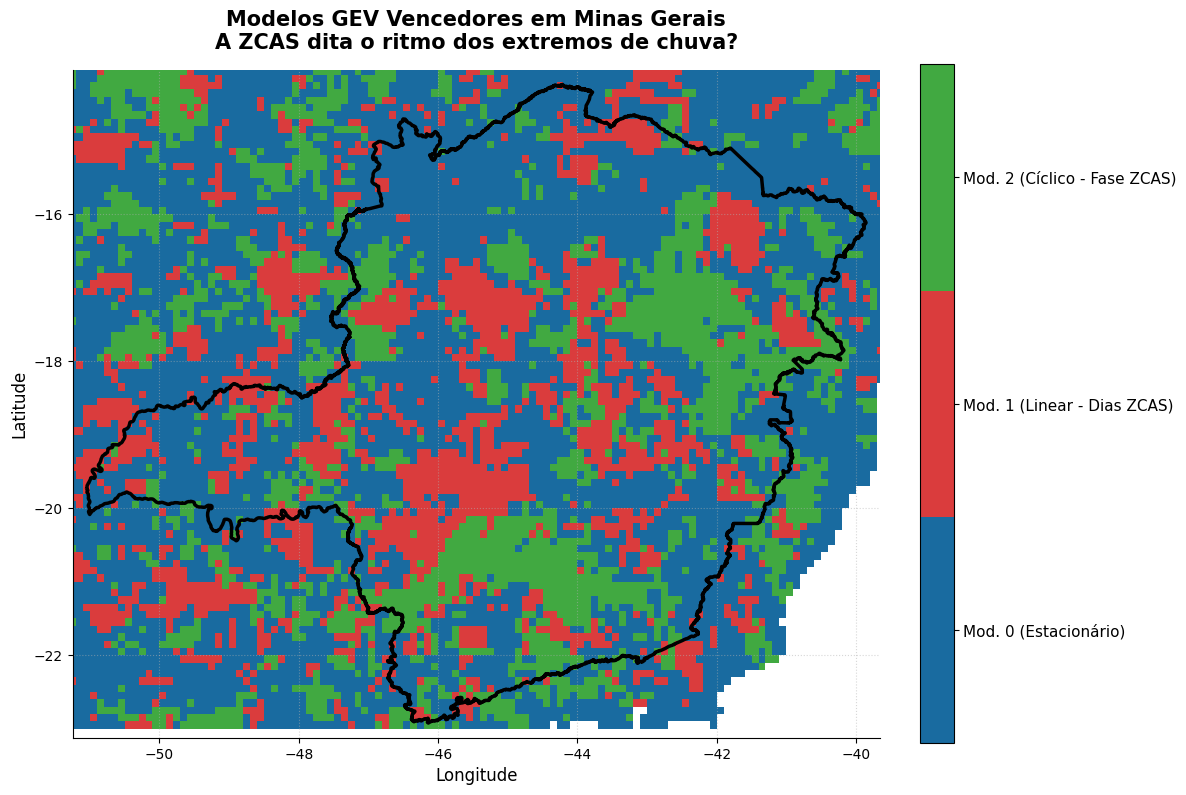

In [14]:
# ==============================================================================
# GRÁFICO DE GEV POR PIXELS PARA MINAS GERAIS - FOCO NA ZCAS (3 MODELOS)
# ==============================================================================
import numpy as np
import xarray as xr
import pandas as pd
import warnings
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geobr

# Desliga os avisos numéricos
warnings.filterwarnings('ignore')

print("1. Preparando o terreno para o estado de Minas Gerais...")

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"

# Recorte Espacial (Bounding Box de Minas Gerais)
ds_ordenado = ds_br.sortby(['latitude', 'longitude'])
ds_mg = ds_ordenado.sel(longitude=slice(-51.5, -39.5), latitude=slice(-23.0, -14.0))

# ==============================================================================
# O PULO DO GATO: SINCRONIZAÇÃO EXATA DOS ANOS (CHÚVA vs ZCAS)
# ==============================================================================
df_zcas = pd.read_csv(caminho_pasta + "indice_zcas_mg.csv")

# Descobre exatamente quais anos existem TANTO na chuva quanto no satélite (os 35 anos)
anos_comuns = np.intersect1d(ds_mg['ano'].values, df_zcas['ano'].values)

# 1. Fatiando o NetCDF de chuva APENAS para os anos em comum
ds_mg_sincronizado = ds_mg.sel(ano=anos_comuns)

chuva_matriz = ds_mg_sincronizado['pr'].values
lats = ds_mg_sincronizado.latitude.values
lons = ds_mg_sincronizado.longitude.values
anos_clima = ds_mg_sincronizado.ano.values

# 2. Fatiando o dataframe da ZCAS APENAS para os anos em comum
df_zcas_alinhado = df_zcas[df_zcas['ano'].isin(anos_comuns)].sort_values('ano')
vetor_zcas = df_zcas_alinhado['dias_ativos_zcas'].values
vetor_anos = df_zcas_alinhado['ano'].values

# ATENÇÃO: Use o período encontrado na análise espectral (periodograma)
periodo_dominante_zcas = 4.0

print(f" -> Anos sincronizados: {len(anos_comuns)} anos validados.")
print(f" -> Malha definida: {len(lats)} latitudes x {len(lons)} longitudes.")

# Otimização do Loop: Criar uma lista SÓ com os pixels válidos
tarefas = []
for i in range(len(lats)):
    for j in range(len(lons)):
        serie_pixel = chuva_matriz[:, i, j]
        # Agora serie_pixel tem tamanho 35, igualzinho ao vetor_zcas!
        if not np.isnan(serie_pixel).all():
            tarefas.append((i, j, serie_pixel))

print(f" -> Total de pixels válidos em MG para processar: {len(tarefas)}")
print("\n2. Ligando os motores paralelos (n_jobs=-1)... Segura o tranco!")

# Função empacotadora para o Joblib adaptada para os 3 modelos da ZCAS
def processar_pixel_paralelo_zcas(i, j, serie_pixel, v_zcas, v_anos, periodo):
    # Retorna o ID do modelo (índice 5 da nova função enxuta de 3 modelos)
    resultado = ajustar_gev_zcas_3_modelos(serie_pixel, v_zcas, v_anos, periodo)
    return (i, j, resultado[5])

# EXECUÇÃO PARALELA
resultados_paralelos = Parallel(n_jobs=-1)(
    delayed(processar_pixel_paralelo_zcas)(i, j, serie, vetor_zcas, vetor_anos, periodo_dominante_zcas)
    for i, j, serie in tqdm(tarefas, desc="Processando Pixels")
)

# Remontando o Quebra-Cabeça Espacial
matriz_vencedores = np.full((len(lats), len(lons)), np.nan)
for i, j, id_modelo in resultados_paralelos:
    matriz_vencedores[i, j] = id_modelo

print("\n3. Cálculos finalizados! Desenhando o mapa de Minas Gerais...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO MAPA COM O CONTORNO DO ESTADO
# ------------------------------------------------------------------------------
estado_mg = geobr.read_state(code_state="MG", year=2020)

fig, ax = plt.subplots(figsize=(12, 10))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# Nova paleta de cores para os 3 modelos
# Azul (Estacionário), Vermelho (Linear), Verde Escuro (Cíclico)
cmap_modelos = ListedColormap(['#005b96', '#d62728', '#2ca02c'])

# Desenha os pixels (Ajustado vmin e vmax para 3 modelos: 0, 1 e 2)
im = ax.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores, cmap=cmap_modelos, vmin=-0.5, vmax=2.5, shading='nearest', alpha=0.9)

estado_mg.boundary.plot(ax=ax, color='black', linewidth=2.5, zorder=3)

# Legenda customizada para 3 modelos
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.7, pad=0.04)
cbar.ax.set_yticklabels([
    'Mod. 0 (Estacionário)',
    'Mod. 1 (Linear - Dias ZCAS)',
    'Mod. 2 (Cíclico - Fase ZCAS)'
], fontsize=11)

ax.set_title("Modelos GEV Vencedores em Minas Gerais\nA ZCAS dita o ritmo dos extremos de chuva?", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.5)

limites = estado_mg.total_bounds
ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)

plt.tight_layout()
plt.show()

TESTES ESTATÍSTICOS

In [9]:
# ==============================================================================
# PAINEL COMPLETO DE PRESSUPOSTOS ESPACIAIS: 5 TESTES ESTATÍSTICOS
# ==============================================================================
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import geobr
import warnings

# Importando o arsenal completo de testes
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from scipy.stats import kendalltau

warnings.filterwarnings('ignore')

print("1. Preparando a varredura completa de pressupostos...")

lats = ds_mg_sincronizado.latitude.values
lons = ds_mg_sincronizado.longitude.values
chuva_matriz = ds_mg_sincronizado['pr'].values
vetor_tempo = np.arange(len(ds_mg_sincronizado.ano.values))

tarefas_testes = []
for i in range(len(lats)):
    for j in range(len(lons)):
        serie_pixel = chuva_matriz[:, i, j]
        if not np.isnan(serie_pixel).all():
            tarefas_testes.append((i, j, serie_pixel))

print(f" -> Total de pixels válidos para testar: {len(tarefas_testes)}")

# ==============================================================================
# MOTOR ESTATÍSTICO: OS 5 TESTES DA TABELA
# ==============================================================================
def calcular_todos_os_testes(i, j, serie, tempo):
    try:
        # 1. Dickey-Fuller (ADF) - Raiz Unitária
        adf_p = adfuller(serie, autolag='AIC')[1]

        # 2. Mann-Kendall (MK) - Tendência Monotônica Linear
        mk_p = kendalltau(tempo, serie)[1]

        # 3. Ljung-Box (LB) - Autocorrelação Linear (Lag 1)
        lb_p = acorr_ljungbox(serie, lags=[1], return_df=False)['lb_pvalue'].values[0]

        # 4. Ljung-Box Quadrado (LB2) - Autocorrelação Não-Linear (Volatilidade)
        serie_centrada = serie - np.mean(serie)
        lb2_p = acorr_ljungbox(serie_centrada**2, lags=[1], return_df=False)['lb_pvalue'].values[0]

        # 5. Teste de Sequências (Runs Test) - Aleatoriedade em relação à média
        runs_p = runstest_1samp(serie, cutoff='mean')[1]

        return (i, j, adf_p, mk_p, lb_p, lb2_p, runs_p)
    except:
        return (i, j, np.nan, np.nan, np.nan, np.nan, np.nan)

print("\n2. Executando os cálculos em paralelo...")
resultados_completos = Parallel(n_jobs=-1)(
    delayed(calcular_todos_os_testes)(i, j, serie, vetor_tempo)
    for i, j, serie in tqdm(tarefas_testes, desc="Calculando Hipóteses")
)

# Preparando as matrizes para guardar os 5 p-valores
matriz_adf = np.full((len(lats), len(lons)), np.nan)
matriz_mk = np.full((len(lats), len(lons)), np.nan)
matriz_lb = np.full((len(lats), len(lons)), np.nan)
matriz_lb2 = np.full((len(lats), len(lons)), np.nan)
matriz_runs = np.full((len(lats), len(lons)), np.nan)

for i, j, p_adf, p_mk, p_lb, p_lb2, p_runs in resultados_completos:
    matriz_adf[i, j] = p_adf
    matriz_mk[i, j] = p_mk
    matriz_lb[i, j] = p_lb
    matriz_lb2[i, j] = p_lb2
    matriz_runs[i, j] = p_runs

print("\n3. Desenhando o Painel Diagnóstico Múltiplo...")

# ==============================================================================
# PLOTAGEM DO PAINEL GIGANTE (2 Linhas x 3 Colunas)
# ==============================================================================
estado_mg = geobr.read_state(code_state="MG", year=2020)
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

limites = estado_mg.total_bounds
alfa = 0.05
cmap_binario = ListedColormap(['#005b96', '#d62728']) # Azul (Comportado), Vermelho (Quebra Pressuposto)

# Função auxiliar para plotar cada mapa de forma padronizada
def desenhar_mapa(ax, matriz, condicao_vermelha, titulo, label_azul, label_vermelha):
    # Condição: 1 para vermelho, 0 para azul
    cat_matriz = np.where(condicao_vermelha, 1, 0)
    cat_matriz = np.where(np.isnan(matriz), np.nan, cat_matriz)

    im = ax.pcolormesh(lon_mesh, lat_mesh, cat_matriz, cmap=cmap_binario, shading='nearest', alpha=0.9)
    estado_mg.boundary.plot(ax=ax, color='black', linewidth=2, zorder=3)

    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
    ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75], shrink=0.6, pad=0.03)
    cbar.ax.set_yticklabels([label_azul, label_vermelha])

# 1. ADF (Não-Estacionariedade) -> Vermelho se p >= 0.05
desenhar_mapa(axes[0, 0], matriz_adf, matriz_adf >= alfa,
              "1. Dickey-Fuller (ADF)", "Estacionária", "Não-Estacionária")

# 2. MK (Tendência) -> Vermelho se p < 0.05
desenhar_mapa(axes[0, 1], matriz_mk, matriz_mk < alfa,
              "2. Mann-Kendall", "Sem Tendência Linear", "Com Tendência Linear")

# 3. LB (Autocorrelação) -> Vermelho se p < 0.05
desenhar_mapa(axes[0, 2], matriz_lb, matriz_lb < alfa,
              "3. Ljung-Box (Lag 1)", "Independente", "Autocorrelacionada")

# 4. LB² (Autocorrelação Não-Linear) -> Vermelho se p < 0.05
desenhar_mapa(axes[1, 0], matriz_lb2, matriz_lb2 < alfa,
              "4. Ljung-Box² (Volatilidade)", "Homocedástica", "Heterocedástica")

# 5. Runs Test (Aleatoriedade) -> Vermelho se p < 0.05
desenhar_mapa(axes[1, 1], matriz_runs, matriz_runs < alfa,
              "5. Teste de Sequências (Runs)", "Aleatória", "Não-Aleatória (Padrão Oculto)")

# Ocultando o 6º gráfico que sobrou na matriz 2x3
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'geobr'

1. Cruzando os laudos estatísticos de todos os pixels...
2. Renderizando o mapa de aptidão...


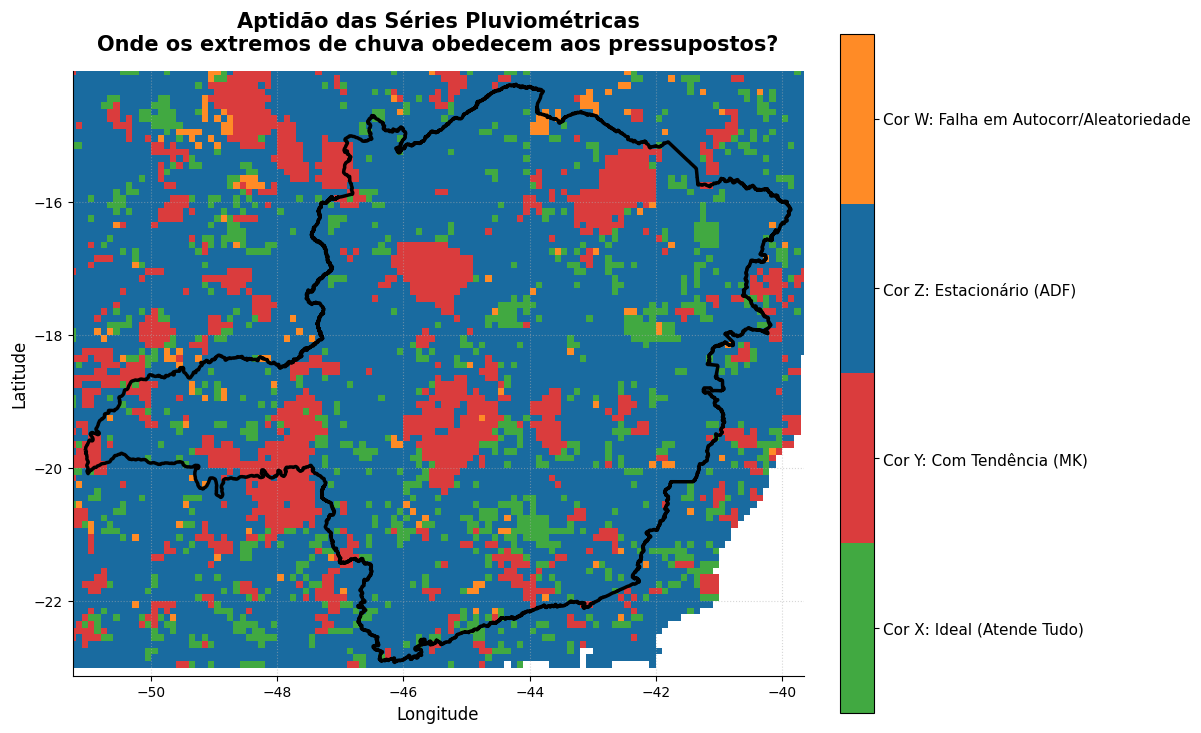


📊 RELATÓRIO DE PRESSUPOSTOS DE MINAS GERAIS:
 -> Total de Pixels Analisados: 10270
 -> Ideal (Aptos para GEV Não-Estac. Cíclica): 1025 (10.0%)
 -> Marcados por Tendência Linear: 1489 (14.5%)
 -> Marcados por Estacionariedade: 7602 (74.0%)
 -> Marcados por Falha Residual: 154 (1.5%)


In [ ]:
# ==============================================================================
# O MAPA DEFINITIVO: SÍNTESE DOS PRESSUPOSTOS ESTATÍSTICOS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geobr

print("1. Cruzando os laudos estatísticos de todos os pixels...")

alfa = 0.05

# Criando as máscaras lógicas para cada situação baseada nos p-valores
# 1. Ideal: ADF >= 0.05 (Não-estac.), MK >= 0.05 (Sem tendência), e demais >= 0.05 (Ruído Branco)
cond_ideal = (matriz_adf >= alfa) & (matriz_mk >= alfa) & (matriz_lb >= alfa) & (matriz_lb2 >= alfa) & (matriz_runs >= alfa)

# 2. Tendência: Apresenta tendência linear (fura a hipótese de apenas oscilação cíclica)
cond_tendencia = (matriz_mk < alfa)

# 3. Estacionariedade: Série é estacionária (não precisa de GEV com covariável)
cond_estacionaria = (matriz_adf < alfa)

# 4. Outras falhas: Quebra Ljung-Box, Ljung-Box² ou Teste de Sequências
cond_outros = (matriz_lb < alfa) | (matriz_lb2 < alfa) | (matriz_runs < alfa)

# Empilhando as condições (a ordem na lista define a prioridade do np.select)
condicoes = [cond_ideal, cond_tendencia, cond_estacionaria, cond_outros]
categorias = [1, 2, 3, 4]  # 1=Ideal, 2=Tendência, 3=Estacionário, 4=Outros

# Aplicando a lógica condicional
matriz_sintese = np.select(condicoes, categorias, default=np.nan)

# Garantindo que o fundo (fora do estado de MG) continue invisível (NaN)
matriz_sintese = np.where(np.isnan(matriz_adf), np.nan, matriz_sintese)

print("2. Renderizando o mapa de aptidão...")

# ==============================================================================
# PLOTAGEM DO MAPA DE SÍNTESE
# ==============================================================================
estado_mg = geobr.read_state(code_state="MG", year=2020)

fig, ax = plt.subplots(figsize=(12, 10))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# Definindo as cores pedidas:
# Verde (Ideal) | Vermelho (Tendência) | Azul (Estacionário) | Laranja (Outros)
cmap_sintese = ListedColormap(['#2ca02c', '#d62728', '#005b96', '#ff7f0e'])

im = ax.pcolormesh(lon_mesh, lat_mesh, matriz_sintese, cmap=cmap_sintese, vmin=0.5, vmax=4.5, shading='nearest', alpha=0.9)

estado_mg.boundary.plot(ax=ax, color='black', linewidth=2.5, zorder=3)

# Legenda clara e interpretativa
cbar = fig.colorbar(im, ax=ax, ticks=[1, 2, 3, 4], shrink=0.7, pad=0.04)
cbar.ax.set_yticklabels([
    'Cor X: Ideal (Atende Tudo)',
    'Cor Y: Com Tendência (MK)',
    'Cor Z: Estacionário (ADF)',
    'Cor W: Falha em Autocorr/Aleatoriedade'
], fontsize=11)

ax.set_title("Aptidão das Séries Pluviométricas\nOnde os extremos de chuva obedecem aos pressupostos?", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.5)

limites = estado_mg.total_bounds
ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)

plt.tight_layout()
plt.show()

# ==============================================================================
# RELATÓRIO QUANTITATIVO (RESUMO PRO TEXTO)
# ==============================================================================
total_validos = np.sum(~np.isnan(matriz_adf))
qtd_ideal = np.sum(matriz_sintese == 1)
qtd_tendencia = np.sum(matriz_sintese == 2)
qtd_estacionaria = np.sum(matriz_sintese == 3)
qtd_outros = np.sum(matriz_sintese == 4)

print("\n📊 RELATÓRIO DE PRESSUPOSTOS DE MINAS GERAIS:")
print(f" -> Total de Pixels Analisados: {total_validos}")
print(f" -> Ideal (Aptos para GEV Não-Estac. Cíclica): {qtd_ideal} ({(qtd_ideal/total_validos)*100:.1f}%)")
print(f" -> Marcados por Tendência Linear: {qtd_tendencia} ({(qtd_tendencia/total_validos)*100:.1f}%)")
print(f" -> Marcados por Estacionariedade: {qtd_estacionaria} ({(qtd_estacionaria/total_validos)*100:.1f}%)")
print(f" -> Marcados por Falha Residual: {qtd_outros} ({(qtd_outros/total_validos)*100:.1f}%)")

Inicialmente a abordagem foi pensando em todo o estado de MG, daí analisou-se como o efeito da variação da temperatura do oceano influencia no aumento ou diminuição das chuvas extremas no estado de MG

In [ ]:
# ==============================================================================
#                    O MAPA DEFINITIVO DE MINAS GERAIS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import geobr
from shapely.geometry import Point
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("1. Preparando as fronteiras de Minas Gerais e garantindo a memória...")

# Puxa o contorno do Estado inteiro diretamente do IBGE
try: estado_mg
except NameError: estado_mg = geobr.read_state(code_state="MG", year=2020)
poligono_mg = estado_mg.geometry.unary_union

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"

# Vacina anti-apagão para a base de dados
try: ds_mg
except NameError:
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_mg = ds_br.sel(latitude=slice(-23.0, -14.0), longitude=slice(-51.5, -39.5))

try: vetor_oni
except NameError:
    df_oni = pd.read_csv(caminho_pasta + "indice_oni_verao.csv")
    anos_comuns = np.intersect1d(ds_mg['ano'].values, df_oni['ano'].values)
    df_oni = df_oni[df_oni['ano'].isin(anos_comuns)].sort_values('ano')
    vetor_oni = df_oni['ONI_Verao'].values

lats = ds_mg.latitude.values
lons = ds_mg.longitude.values

print("2. Mapeando os pixels terrestres dentro de MG (Pré-filtro)...")
pontos_validos = []
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        # Apenas adiciona na fila de cálculo se o ponto cair dentro de MG
        if poligono_mg.contains(Point(lon, lat)):
            pontos_validos.append((i, j, lat, lon))

print(f" -> Encontrados {len(pontos_validos)} pixels válidos em MG. Ligando os motores...")

# Matrizes para guardar resultados
pixels_m0, pixels_m1, pixels_m2, pixels_m3 = [], [], [], []
pixels_alvo_mu1, valores_mu1 = [], []

# ------------------------------------------------------------------------------
# O GRANDE LOOP (Com barra de progresso visual)
# ------------------------------------------------------------------------------
# NOTA: O código vai usar a função 'ajustar_gev_4_modelos' que estiver na memória.
# Se você rodou a versão com BIC por último, ele usará o BIC. Se rodou AIC, usará AIC.
for i, j, lat, lon in tqdm(pontos_validos, desc="Calculando GEV em MG", unit="pixel"):
    serie_pixel = ds_mg['pr'].isel(latitude=i, longitude=j).values

    if not np.isnan(serie_pixel).all() and len(serie_pixel) == len(vetor_oni):
        # res = [mu0, mu1, sigma0, sigma1, xi, criterio_vencedor, id_modelo]
        res = ajustar_gev_4_modelos(serie_pixel, vetor_oni)
        id_modelo = res[6]

        pixel_formatado = [0, 0, lat, lon]

        if id_modelo == 0: pixels_m0.append(pixel_formatado)
        elif id_modelo == 1: pixels_m1.append(pixel_formatado)
        elif id_modelo == 2: pixels_m2.append(pixel_formatado)
        elif id_modelo == 3: pixels_m3.append(pixel_formatado)

        # Guarda o parâmetro mu_1 se o modelo vencedor afetar a média (Mod 1 ou 3)
        if id_modelo in [1, 3]:
            pixels_alvo_mu1.append(pixel_formatado)
            valores_mu1.append(res[1])

print("\n3. Renderizando o Painel Definitivo do Estado...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL DUPLO GIGANTE
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Cidades de Referência
ref_cidades = {
    'Belo Horizonte': (-19.91, -43.93),
    'Viçosa': (-20.75, -42.87)
}

# --- MAPA 1: DISTRIBUIÇÃO ESPACIAL DOS MODELOS ---
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=1.5)

if pixels_m0: ax1.scatter([p[3] for p in pixels_m0], [p[2] for p in pixels_m0], c='#005b96', marker='s', s=40, label='Mod. 0 (Estacionário)')
if pixels_m1: ax1.scatter([p[3] for p in pixels_m1], [p[2] for p in pixels_m1], c='#d62728', marker='s', s=40, label='Mod. 1 (Média)')
if pixels_m2: ax1.scatter([p[3] for p in pixels_m2], [p[2] for p in pixels_m2], c='#ff7f0e', marker='s', s=40, label='Mod. 2 (Variabilidade)')
if pixels_m3: ax1.scatter([p[3] for p in pixels_m3], [p[2] for p in pixels_m3], c='#9467bd', marker='s', s=40, label='Mod. 3 (Média + Var)')

for nome, (lat_c, lon_c) in ref_cidades.items():
    ax1.plot(lon_c, lat_c, marker='*', color='yellow', markersize=16, markeredgecolor='black', label=nome)

ax1.set_title("Modelos Vencedores - Minas Gerais\nOnde o El Niño afeta o clima extremo?", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9)

# --- MAPA 2: INTENSIDADE DO IMPACTO NA MÉDIA (mu_1) ---
estado_mg.boundary.plot(ax=ax2, color='black', linewidth=1.5)

if len(pixels_alvo_mu1) > 0 and len(valores_mu1) > 0:
    lons_alvo = [p[3] for p in pixels_alvo_mu1]
    lats_alvo = [p[2] for p in pixels_alvo_mu1]
    limite = max(abs(np.min(valores_mu1)), abs(np.max(valores_mu1)))

    scatter = ax2.scatter(lons_alvo, lats_alvo, c=valores_mu1, cmap='RdBu',
                          marker='s', s=50, vmin=-limite, vmax=limite,
                          edgecolor='gray', linewidth=0.1)

    cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label(r'Impacto em mm ($\mu_1$)' + '\n< 0: Redução | > 0: Aumento', fontsize=12)

for nome, (lat_c, lon_c) in ref_cidades.items():
    ax2.plot(lon_c, lat_c, marker='*', color='yellow', markersize=16, markeredgecolor='black')

ax2.set_title(r"Intensidade do Impacto nos Extremos ($\mu_1$)" + "\nA chuva sobe ou desce com o El Niño?", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Longitude", fontsize=12)
ax2.set_ylabel("Latitude", fontsize=12)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# --- RELATÓRIO DO ESTADO ---
total_processados = len(pixels_m0) + len(pixels_m1) + len(pixels_m2) + len(pixels_m3)
print("\n📊 RELATÓRIO DO ESTADO DE MINAS GERAIS:")
print(f" -> Total de Pixels Processados com Sucesso: {total_processados}")
print(f" -> Estacionários (Modelo 0): {len(pixels_m0)} ({(len(pixels_m0)/total_processados*100):.1f}%)")
print(f" -> Impacto na Média (Modelo 1): {len(pixels_m1)} ({(len(pixels_m1)/total_processados*100):.1f}%)")
print(f" -> Impacto na Variabilidade (Modelo 2): {len(pixels_m2)} ({(len(pixels_m2)/total_processados*100):.1f}%)")
print(f" -> Impacto Total Média+Var (Modelo 3): {len(pixels_m3)} ({(len(pixels_m3)/total_processados*100):.1f}%)")

1. Preparando as fronteiras de Minas Gerais e garantindo a memória...
2. Mapeando os pixels terrestres dentro de MG (Pré-filtro)...
 -> Encontrados 5020 pixels válidos em MG. Ligando os motores...


Calculando GEV em MG:  14%|█▍        | 710/5020 [05:07<31:09,  2.31pixel/s]


KeyboardInterrupt: 

Pensando em identificação das regiões e como o El nino afeta cada região do estado, dividiu-se o estado em mesoregiões e posteriormente, foram analisadas as influências para aumento ou redução de precipitações máximas diárias em cada região analisada.

---



Buscando as fronteiras das mesorregiões de MG no servidor do IPEA...


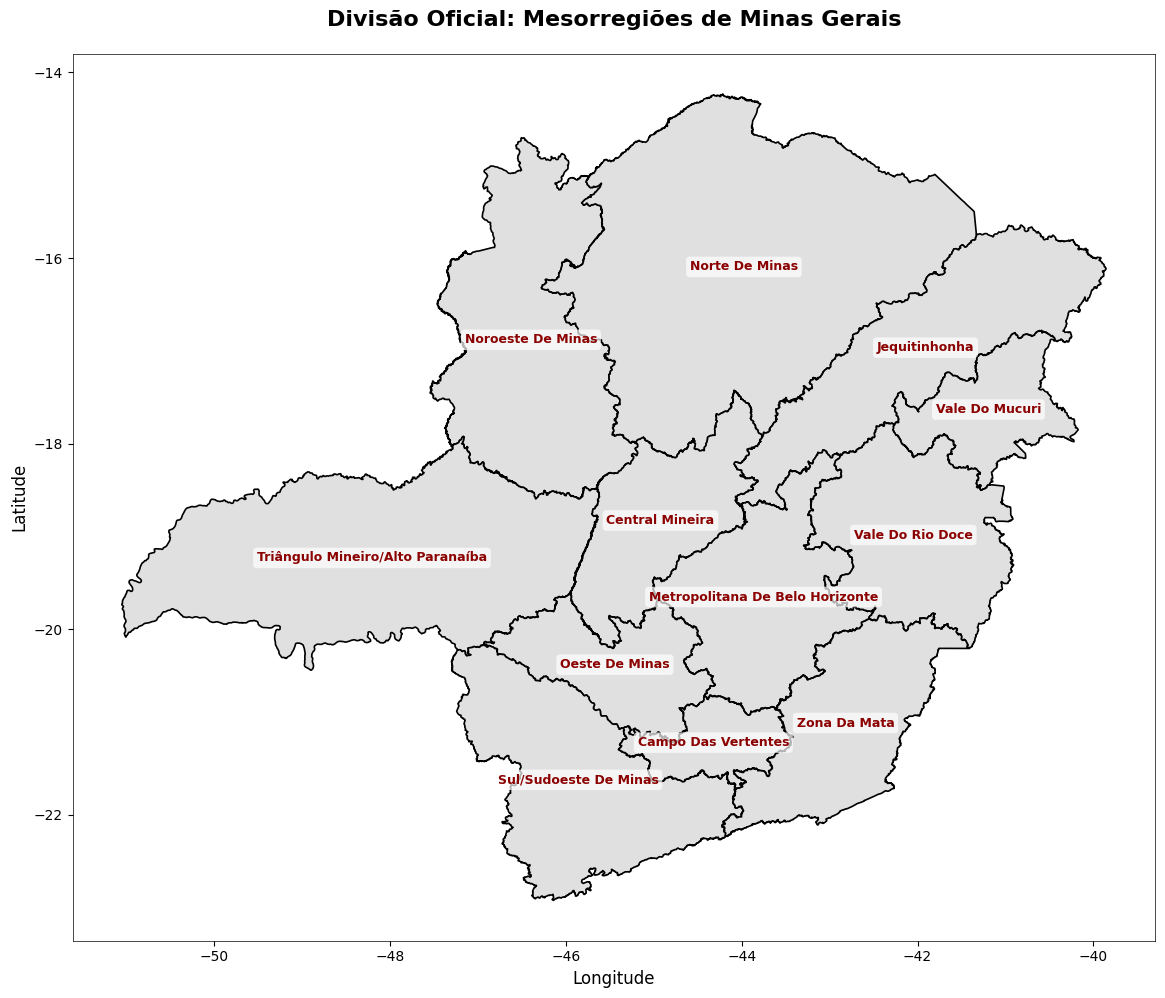


Lista Oficial de Mesorregiões Prontas para Recorte:
 -> Noroeste De Minas
 -> Norte De Minas
 -> Jequitinhonha
 -> Vale Do Mucuri
 -> Triângulo Mineiro/Alto Paranaíba
 -> Central Mineira
 -> Metropolitana De Belo Horizonte
 -> Vale Do Rio Doce
 -> Oeste De Minas
 -> Sul/Sudoeste De Minas
 -> Campo Das Vertentes
 -> Zona Da Mata


In [ ]:
# ==============================================================================
#               MAPEAMENTO DAS MESORREGIÕES DE MINAS GERAIS
# ==============================================================================
import geobr
import matplotlib.pyplot as plt

print("Buscando as fronteiras das mesorregiões de MG no servidor do IPEA...")

# Baixa as mesorregiões oficiais do estado
meso_mg = geobr.read_meso_region(code_meso="MG", year=2020)

# Configura a figura
fig, ax = plt.subplots(figsize=(12, 10))

# Plota os polígonos com uma cor neutra
meso_mg.plot(ax=ax, facecolor='#e0e0e0', edgecolor='black', linewidth=1.2)

# Adiciona os nomes das regiões bem no centro (centróide) de cada polígono
for idx, row in meso_mg.iterrows():
    centroide = row.geometry.centroid
    # Ajuste fino para o nome não vazar muito
    ax.annotate(text=row['name_meso'],
                xy=(centroide.x, centroide.y),
                ha='center', va='center',
                fontsize=9, color='darkred', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))

# Acabamento visual
ax.set_title("Divisão Oficial: Mesorregiões de Minas Gerais", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Remove as bordas feias do gráfico
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

# Imprime a lista exata de nomes que vamos usar para filtrar os dados
print("\nLista Oficial de Mesorregiões Prontas para Recorte:")
for nome in meso_mg['name_meso'].unique():
    print(f" -> {nome}")

In [ ]:
# ==============================================================================
# NOVA FUNÇÃO GEV CONDICIONAL (GUIADA PELOS PRESSUPOSTOS)
# ==============================================================================
from scipy.optimize import minimize
from scipy.stats import genextreme
import numpy as np

def ajustar_gev_condicional(series_chuva, vetor_zcas, vetor_anos, periodo_t, categoria_pixel):
    """
    Roteamento:
    - Se categoria_pixel == 3 (Estacionária): Ajusta apenas o Modelo 0.
    - Se categoria_pixel != 3 (Não-Estacionária): Competição AIC (M0, Tempo, ZCAS_Lin, ZCAS_Cicl).
    Retorno: [mu0, mu_tempo, mu_zcas_ou_amp, sigma, xi, ID_Modelo]
    """
    validos = ~np.isnan(series_chuva) & ~np.isnan(vetor_zcas) & ~np.isnan(vetor_anos)
    y = series_chuva[validos]
    z = vetor_zcas[validos]
    t_anos = vetor_anos[validos]

    if len(y) < 30 or np.isnan(categoria_pixel):
        return [np.nan] * 6

    # Eixo de tempo (t = 0, 1, 2...) para o Modelo de Tendência Linear e Cíclico
    t = t_anos - np.min(t_anos)
    cos_t = np.cos(2 * np.pi * t / periodo_t)
    sin_t = np.sin(2 * np.pi * t / periodo_t)

    # --------------------------------------------------------------------------
    # MODELO 0: ESTACIONÁRIO (Baseline)
    # --------------------------------------------------------------------------
    def nll_m0(p):
        mu, sigma, xi = p
        if sigma <= 0: return 1e10
        return -np.sum(genextreme.logpdf(y, -xi, loc=mu, scale=sigma))

    res0 = minimize(nll_m0, [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')

    # REGRA DE OURO: Se for Categoria 3, retorna imediatamente o M0 (Trava a Seleção)
    if categoria_pixel == 3:
        if res0.success:
            return [res0.x[0], 0, 0, res0.x[1], res0.x[2], 0] # ID = 0
        else:
            return [np.nan] * 6

    # ==========================================================================
    # COMPETIÇÃO PARA SÉRIES NÃO-ESTACIONÁRIAS (Categorias 1, 2 e 4)
    # ==========================================================================
    resultados_aic = {}
    parametros = {}

    if res0.success:
        resultados_aic[0] = 2 * 3 + 2 * res0.fun
        parametros[0] = [res0.x[0], 0, 0, res0.x[1], res0.x[2]]

    # --------------------------------------------------------------------------
    # MODELO 1: TENDÊNCIA LINEAR NO TEMPO (mu = mu0 + mu_t * t)
    # --------------------------------------------------------------------------
    def nll_m1(p):
        mu0, mu_t, sigma, xi = p
        if sigma <= 0: return 1e10
        loc_t = mu0 + mu_t * t
        return -np.sum(genextreme.logpdf(y, -xi, loc=loc_t, scale=sigma))

    res1 = minimize(nll_m1, [res0.x[0], 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res1.success:
        resultados_aic[1] = 2 * 4 + 2 * res1.fun
        # Guarda mu_t na posição 1 do vetor
        parametros[1] = [res1.x[0], res1.x[1], 0, res1.x[2], res1.x[3]]

    # --------------------------------------------------------------------------
    # MODELO 2: INFLUÊNCIA LINEAR DA ZCAS (mu = mu0 + mu_z * ZCAS)
    # --------------------------------------------------------------------------
    def nll_m2(p):
        mu0, mu_z, sigma, xi = p
        if sigma <= 0: return 1e10
        loc_t = mu0 + mu_z * z
        return -np.sum(genextreme.logpdf(y, -xi, loc=loc_t, scale=sigma))

    res2 = minimize(nll_m2, [res0.x[0], 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res2.success:
        resultados_aic[2] = 2 * 4 + 2 * res2.fun
        # Guarda mu_z na posição 2 do vetor
        parametros[2] = [res2.x[0], 0, res2.x[1], res2.x[2], res2.x[3]]

    # --------------------------------------------------------------------------
    # MODELO 3: INFLUÊNCIA CÍCLICA DA ZCAS (Fase da onda)
    # --------------------------------------------------------------------------
    def nll_m3(p):
        mu0, mu_c, mu_s, sigma, xi = p
        if sigma <= 0: return 1e10
        loc_t = mu0 + mu_c * cos_t + mu_s * sin_t
        return -np.sum(genextreme.logpdf(y, -xi, loc=loc_t, scale=sigma))

    res3 = minimize(nll_m3, [res0.x[0], 0, 0, res0.x[1], res0.x[2]], method='Nelder-Mead')
    if res3.success:
        resultados_aic[3] = 2 * 5 + 2 * res3.fun
        amplitude = np.sqrt(res3.x[1]**2 + res3.x[2]**2)
        # Guarda a Amplitude na posição 2 do vetor
        parametros[3] = [res3.x[0], 0, amplitude, res3.x[3], res3.x[4]]

    # --------------------------------------------------------------------------
    # SELEÇÃO DO VENCEDOR (AIC)
    # --------------------------------------------------------------------------
    if not resultados_aic:
        return [np.nan] * 6

    melhor_id = min(resultados_aic, key=resultados_aic.get)
    return parametros[melhor_id] + [melhor_id]

1. Ligando os motores paralelos para a GEV Condicional...


Modelando os Extremos:   0%|          | 0/10270 [00:00<?, ?it/s]


2. Cálculos finalizados! Desenhando o mapa de Minas Gerais...


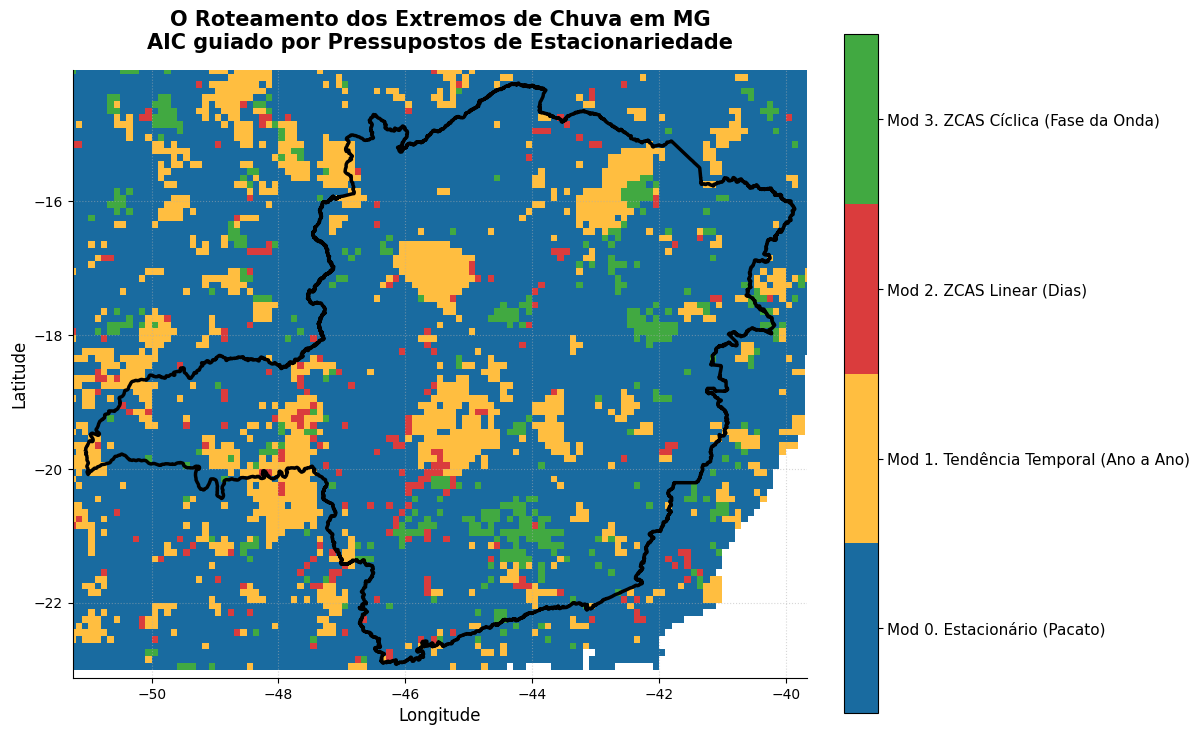

In [ ]:
# ==============================================================================
# VARREDURA ESPACIAL E PLOTAGEM DO MAPA DEFINITIVO
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import geobr

print("1. Ligando os motores paralelos para a GEV Condicional...")

# O período que encontramos no seu gráfico de espectro da ZCAS
periodo_dominante_zcas = 4.0

def processar_pixel_condicional(i, j, serie, v_zcas, v_anos, periodo, cat_pixel):
    resultado = ajustar_gev_condicional(serie, v_zcas, v_anos, periodo, cat_pixel)
    return (i, j, resultado[5]) # Retorna a coordenada e o ID do Modelo Vencedor

# Roda o processamento passando a categoria que definimos no passo anterior!
resultados_condicionais = Parallel(n_jobs=-1)(
    delayed(processar_pixel_condicional)(i, j, serie, vetor_zcas, vetor_anos, periodo_dominante_zcas, matriz_sintese[i, j])
    for i, j, serie in tqdm(tarefas, desc="Modelando os Extremos")
)

# Remontando a Matriz de Vencedores
matriz_vencedores_final = np.full((len(lats), len(lons)), np.nan)
for i, j, id_modelo in resultados_condicionais:
    matriz_vencedores_final[i, j] = id_modelo

print("\n2. Cálculos finalizados! Desenhando o mapa de Minas Gerais...")

# ------------------------------------------------------------------------------
# MAPA: QUAL A FORÇA MOTRIZ DAS CHUVAS EXTREMAS?
# ------------------------------------------------------------------------------
estado_mg = geobr.read_state(code_state="MG", year=2020)
fig, ax = plt.subplots(figsize=(12, 10))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# Novas cores amarradas à sua regra:
# 0 = Azul (Estacionário / Sem efeito de tempo ou ZCAS)
# 1 = Amarelo/Dourado (Tendência apenas no Tempo)
# 2 = Vermelho (ZCAS Linear)
# 3 = Verde (ZCAS Cíclica)
cmap_modelos = ListedColormap(['#005b96', '#ffb72b', '#d62728', '#2ca02c'])

im = ax.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores_final, cmap=cmap_modelos, vmin=-0.5, vmax=3.5, shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax, color='black', linewidth=2.5, zorder=3)

# Legenda atualizada
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7, pad=0.04)
cbar.ax.set_yticklabels([
    'Mod 0. Estacionário (Pacato)',
    'Mod 1. Tendência Temporal (Ano a Ano)',
    'Mod 2. ZCAS Linear (Dias)',
    'Mod 3. ZCAS Cíclica (Fase da Onda)'
], fontsize=11)

ax.set_title("O Roteamento dos Extremos de Chuva em MG\nAIC guiado por Pressupostos de Estacionariedade", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.5)

limites = estado_mg.total_bounds
ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)

plt.tight_layout()
plt.show()

In [1]:
# ==============================================================================
# QUANTIFICAÇÃO MESTRE: EXTRAÇÃO E MAPEAMENTO DAS INTENSIDADES DA ZCAS
# ==============================================================================
import numpy as np
import xarray as xr
import pandas as pd
import warnings
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geobr

warnings.filterwarnings('ignore')

print("1. Sincronizando dados e preparando matrizes de intensidade...")

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"

# 1.1 Garante o recorte de MG e o alinhamento com o índice ZCAS
ds_ordenado = ds_br.sortby(['latitude', 'longitude'])
ds_mg = ds_ordenado.sel(longitude=slice(-51.5, -39.5), latitude=slice(-23.0, -14.0))

df_zcas = pd.read_csv(caminho_pasta + "indice_zcas_mg.csv")
anos_comuns = np.intersect1d(ds_mg['ano'].values, df_zcas['ano'].values)

ds_mg_sincronizado = ds_mg.sel(ano=anos_comuns)
chuva_matriz = ds_mg_sincronizado['pr'].values
lats = ds_mg_sincronizado.latitude.values
lons = ds_mg_sincronizado.longitude.values

df_zcas_alinhado = df_zcas[df_zcas['ano'].isin(anos_comuns)].sort_values('ano')
vetor_zcas = df_zcas_alinhado['dias_ativos_zcas'].values
vetor_anos = df_zcas_alinhado['ano'].values

periodo_dominante_zcas = 4.0  # Frequência extraída do seu periodograma

# 1.2 Cria a lista de tarefas com os pixels válidos
tarefas = []
for i in range(len(lats)):
    for j in range(len(lons)):
        serie_pixel = chuva_matriz[:, i, j]
        if not np.isnan(serie_pixel).all():
            tarefas.append((i, j, serie_pixel))

# 1.3 Prepara as matrizes vazias para receber a física dos modelos
matriz_vencedores = np.full((len(lats), len(lons)), np.nan)
matriz_intensidade_linear = np.full((len(lats), len(lons)), np.nan)
matriz_amplitude_ciclica = np.full((len(lats), len(lons)), np.nan)

print("\n2. Ligando o motor paralelo para extrair os coeficientes estimados...")

def processar_intensidades_pixel(i, j, serie, v_zcas, v_anos, periodo, cat_pixel):
    # Executa a função condicional guiada pelos pressupostos
    res = ajustar_gev_condicional(serie, v_zcas, v_anos, periodo, cat_pixel)
    # Retorno esperado: [mu0, mu_tempo, mu_zcas_ou_amp, sigma, xi, ID_Modelo]
    return (i, j, res[5], res[1], res[2])

# Execução em paralelo cruzando os pressupostos salvos na 'matriz_sintese'
resultados = Parallel(n_jobs=-1)(
    delayed(processar_intensidades_pixel)(i, j, serie, vetor_zcas, vetor_anos, periodo_dominante_zcas, matriz_sintese[i, j])
    for i, j, serie in tqdm(tarefas, desc="Quantificando Impactos")
)

# Organizando as saídas matemáticas nas matrizes espaciais correspondentes
for i, j, id_modelo, mu_tempo, mu_zcas_ou_amp in resultados:
    matriz_vencedores[i, j] = id_modelo

    if id_modelo == 2:
        # Modelo Linear venceu: guarda a taxa de variação (mm/dia de ZCAS)
        matriz_intensidade_linear[i, j] = mu_zcas_ou_amp
    elif id_modelo == 3:
        # Modelo Cíclico venceu: guarda a Amplitude total da oscilação (mm)
        matriz_amplitude_ciclica[i, j] = mu_zcas_ou_amp

# 1.4 Salvando o Dataset completo no Drive para segurança
ds_intensidades = xr.Dataset(
    {
        "modelo_vencedor": (["latitude", "longitude"], matriz_vencedores),
        "impacto_linear_zcas": (["latitude", "longitude"], matriz_intensidade_linear),
        "amplitude_ciclica_zcas": (["latitude", "longitude"], matriz_amplitude_ciclica)
    },
    coords={"latitude": lats, "longitude": lons}
)
ds_intensidades.to_netcdf(caminho_pasta + "GEV_ZCAS_intensidades_mg.nc")
print("\n✅ Sucesso! Matrizes salvas e exportadas para o Drive.")

# ==============================================================================
# 3. RENDERIZAÇÃO DO PAINEL DUPLO DE INTENSIDADES
# ==============================================================================
print("\n3. Desenhando os mapas de intensidade...")
estado_mg = geobr.read_state(code_state="MG", year=2020)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)
limites = estado_mg.total_bounds

# --- MAPA 1: CONTEXTO LINEAR (Taxa de variação no Modelo 2) ---
# Usa mapa de cores divergente/sequencial para mostrar o ganho de chuva
im1 = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_intensidade_linear, cmap='YlOrRd', shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=2, zorder=3)
ax1.set_title("Contexto Linear (Modelo 2 Vencedor)\nGanho de chuva extrema por dia ativo de ZCAS", fontsize=13, fontweight='bold', pad=12)
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label(r'Sensibilidade Linear $\mu_1$ (mm / dia de ZCAS)', fontsize=11)

# --- MAPA 2: CONTEXTO CÍCLICO (Amplitude de oscilação no Modelo 3) ---
# Usa mapa de cores focado na força física da onda
im2 = ax2.pcolormesh(lon_mesh, lat_mesh, matriz_amplitude_ciclica, cmap='Speed_r', shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax2, color='black', linewidth=2, zorder=3)
ax2.set_title("Contexto Cíclico (Modelo 3 Vencedor)\nAmplitude máxima da oscilação interanual", fontsize=13, fontweight='bold', pad=12)
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Amplitude do Ciclo Climático (mm)', fontsize=11)

# Padronização dos eixos geográficos
for ax in [ax1, ax2]:
    ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
    ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.plot(-42.87, -20.75, marker='*', color='yellow', markersize=14, markeredgecolor='black', zorder=4) # Viçosa

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'geobr'

Em especial, analisou-se a Zona da Mata mineira e a influência da variação da temperatura do oceano nas precipitações máximas diárias na região.

---



In [ ]:
# ==============================================================================
# CÉLULA 14: ZOOM ESPACIAL - MODELOS E IMPACTO NA ZONA DA MATA
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Desenhando o mapa de alta resolução da região...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Coordenadas aproximadas de Viçosa para referência espacial
lat_vicosa, lon_vicosa = -20.75, -42.88

# ------------------------------------------------------------------------------
# MAPA 1: DISTRIBUIÇÃO DOS MODELOS (O Raio-X Categórico)
# ------------------------------------------------------------------------------
# Desenha a fronteira da região
gdf_regiao.boundary.plot(ax=ax1, color='black', linewidth=2)

# Plota os pixels como pequenos quadrados (marker='s')
if pixels_m0: ax1.scatter([p[3] for p in pixels_m0], [p[2] for p in pixels_m0], c='#005b96', marker='s', s=90, label='Mod. 0 (Estacionário)')
if pixels_m1: ax1.scatter([p[3] for p in pixels_m1], [p[2] for p in pixels_m1], c='#d62728', marker='s', s=90, label='Mod. 1 (Média)')
if pixels_m2: ax1.scatter([p[3] for p in pixels_m2], [p[2] for p in pixels_m2], c='#ff7f0e', marker='s', s=90, label='Mod. 2 (Variabilidade)')
if pixels_m3: ax1.scatter([p[3] for p in pixels_m3], [p[2] for p in pixels_m3], c='#9467bd', marker='s', s=90, label='Mod. 3 (Média + Var)')

# Marcador de Viçosa
ax1.plot(lon_vicosa, lat_vicosa, marker='*', color='yellow', markersize=20, markeredgecolor='black', label='Viçosa')

ax1.set_title(f"Modelos Vencedores (AIC)\nOnde o El Niño afeta o clima?", fontsize=14, fontweight='bold')
ax1.set_xlabel("Longitude", fontsize=11)
ax1.set_ylabel("Latitude", fontsize=11)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.9)

# ------------------------------------------------------------------------------
# MAPA 2: A INTENSIDADE DO IMPACTO (O Valor de mu_1)
# ------------------------------------------------------------------------------
gdf_regiao.boundary.plot(ax=ax2, color='black', linewidth=2)

if len(pixels_alvo) > 0:
    lons_alvo = [p[3] for p in pixels_alvo]
    lats_alvo = [p[2] for p in pixels_alvo]

    # Define o limite do colormap para o "zero" ficar exatamente no branco
    limite = max(abs(np.min(valores_mu1)), abs(np.max(valores_mu1)))

    # Plota o mapa de calor divergente (RdBu: Red to Blue)
    scatter = ax2.scatter(lons_alvo, lats_alvo, c=valores_mu1, cmap='RdBu',
                          marker='s', s=100, vmin=-limite, vmax=limite,
                          edgecolor='gray', linewidth=0.3)

    # Barra de cores lateral
    cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label('Impacto em mm ($\mu_1$)\n< 0: Redução | > 0: Aumento', fontsize=11)

# Marcador de Viçosa
ax2.plot(lon_vicosa, lat_vicosa, marker='*', color='yellow', markersize=20, markeredgecolor='black')

ax2.set_title(f"Intensidade do Impacto nos Extremos ($\mu_1$)\nA chuva sobe ou desce com o El Niño?", fontsize=14, fontweight='bold')
ax2.set_xlabel("Longitude", fontsize=11)
ax2.set_ylabel("Latitude", fontsize=11)

# Remove as bordas desnecessárias para ficar elegante
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Agora é o processo de testar a influência da Zona de convergência do atlantico sul.

---



Vou testar inicialmente apenas para Viçosa, depois generalizar para as demais cidades.

1. Carregando os dados e isolando as coordenadas...
2. Alinhamento Temporal (O Intersect dos Anos)...
 -> Séries alinhadas! Temos 35 anos de dados sincronizados.

3. Rodando o Motor GEV (ZCAS como Covariável)...
📊 RESULTADOS DO AJUSTE PARA VIÇOSA:
 -> Modelo Vencedor (BIC): Modelo 1
 -> Conclusão: A ZCAS tem impacto direto! Parâmetro mu_1 = 0.433
 -> Interpretação: Para cada dia a mais de ZCAS no verão, a média das chuvas extremas sobe 0.433 mm.


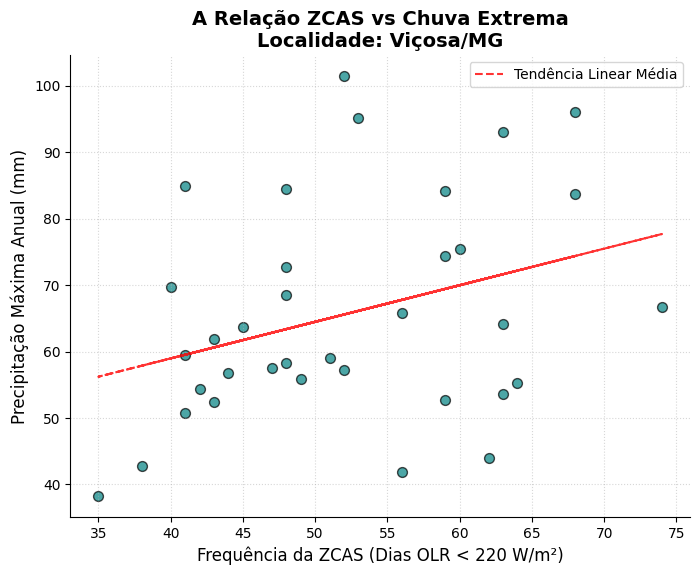

In [ ]:
# ==============================================================================
# CÉLULA 34: TESTE DO MODELO GEV ISOLANDO A ZCAS (EXEMPLO: VIÇOSA-MG)
# ==============================================================================
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

print("1. Carregando os dados e isolando as coordenadas...")
# Coordenadas aproximadas de Viçosa (ajuste se necessário para cair num pixel válido)
lat_alvo = -20.75
lon_alvo = -42.87

# Seleciona o pixel mais próximo na sua matriz de chuva
pixel_chuva = ds_mg.sel(latitude=lat_alvo, longitude=lon_alvo, method='nearest')
df_chuva = pixel_chuva['pr'].to_dataframe().reset_index()

# Carrega o índice ZCAS que acabamos de criar na célula anterior
df_zcas = indice_zcas.copy()

print("2. Alinhamento Temporal (O Intersect dos Anos)...")
# Descobre quais anos existem em comum entre a chuva e o satélite
anos_comuns = np.intersect1d(df_chuva['ano'].values, df_zcas['ano'].values)

# Filtra as duas tabelas para terem exatamente a mesma quantidade de linhas
chuva_alinhada = df_chuva[df_chuva['ano'].isin(anos_comuns)].sort_values('ano')
zcas_alinhada = df_zcas[df_zcas['ano'].isin(anos_comuns)].sort_values('ano')

# Extrai os vetores puros para jogar na matemática
vetor_y = chuva_alinhada['pr'].values
vetor_x_zcas = zcas_alinhada['dias_ativos_zcas'].values

print(f" -> Séries alinhadas! Temos {len(vetor_y)} anos de dados sincronizados.")

print("\n3. Rodando o Motor GEV (ZCAS como Covariável)...")
# NOTA: Usaremos a mesma função base, apenas passando o vetor da ZCAS no lugar do ONI.
# Certifique-se de que a função ajustar_gev_4_modelos (ou a versão BIC) está carregada na memória.
resultado_zcas = ajustar_gev_4_modelos(vetor_y, vetor_x_zcas)

if not np.isnan(resultado_zcas[0]):
    mu0, mu1, sigma0, sigma1, xi, bic, id_modelo = resultado_zcas

    print("📊 RESULTADOS DO AJUSTE PARA VIÇOSA:")
    print(f" -> Modelo Vencedor (BIC): Modelo {id_modelo}")

    if id_modelo == 0:
        print(" -> Conclusão: O modelo Estacionário venceu. A ZCAS não altera a GEV de forma estatisticamente forte aqui.")
    else:
        print(f" -> Conclusão: A ZCAS tem impacto direto! Parâmetro mu_1 = {mu1:.3f}")
        print(f" -> Interpretação: Para cada dia a mais de ZCAS no verão, a média das chuvas extremas sobe {mu1:.3f} mm.")
else:
    print("Erro no ajuste numérico para este pixel.")

# ------------------------------------------------------------------------------
# PLOTAGEM DE DISPERSÃO: Chuva Máxima vs Dias de ZCAS
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(vetor_x_zcas, vetor_y, color='teal', alpha=0.7, edgecolor='black', s=50)

# Adiciona linha de tendência linear simples para visualização
z = np.polyfit(vetor_x_zcas, vetor_y, 1)
p = np.poly1d(z)
plt.plot(vetor_x_zcas, p(vetor_x_zcas), "r--", alpha=0.8, label='Tendência Linear Média')

plt.title(f"A Relação ZCAS vs Chuva Extrema\nLocalidade: Viçosa/MG", fontsize=14, fontweight='bold')
plt.xlabel("Frequência da ZCAS (Dias OLR < 220 W/m²)", fontsize=12)
plt.ylabel("Precipitação Máxima Anual (mm)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Agora para toda a MG

1. Preparando o terreno para a varredura da ZCAS em Minas Gerais...
 -> Anos sincronizados: 35 anos (Satélite + Pluviômetros).
2. Mapeando os pixels terrestres válidos...
 -> Total de pixels válidos para processar: 10270

3. Ligando os motores paralelos (ZCAS)...


Calculando GEV-ZCAS:   0%|          | 0/10270 [00:00<?, ?it/s]


4. Cálculos finalizados! Desenhando o mapa de impacto da ZCAS...


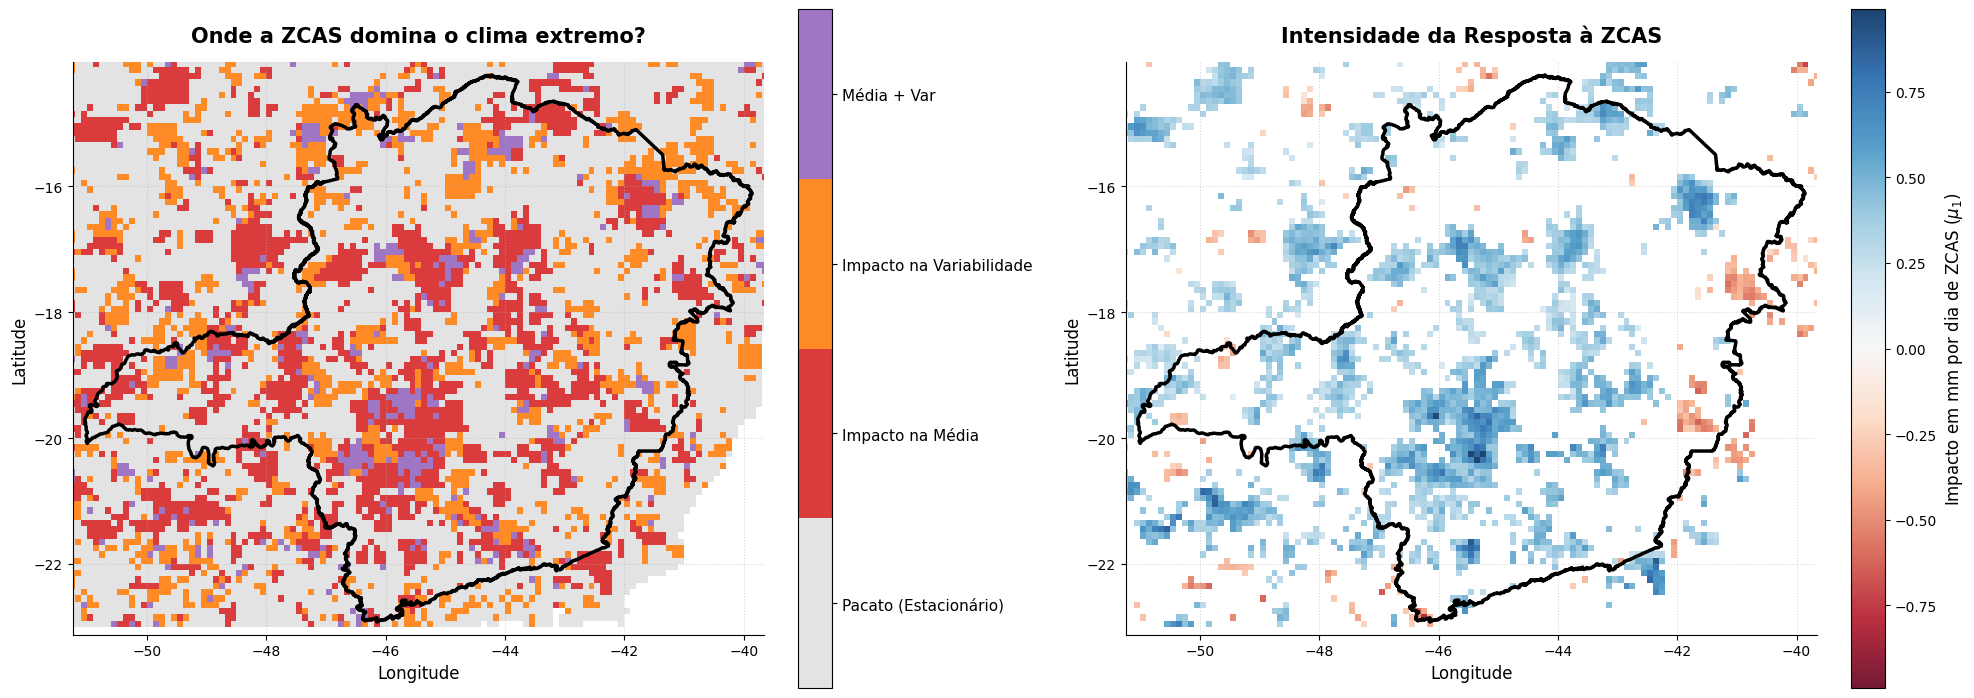

In [ ]:
# ==============================================================================
# CÉLULA 35: MOTOR PARALELO PARA MG (COVARIÁVEL: ZCAS)
# ==============================================================================
import numpy as np
import xarray as xr
import warnings
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geobr

warnings.filterwarnings('ignore')

print("1. Preparando o terreno para a varredura da ZCAS em Minas Gerais...")

# 1.1 Garante o contorno do estado
try: estado_mg
except NameError: estado_mg = geobr.read_state(code_state="MG", year=2020)

# 1.2 Alinhamento Temporal Mestre (Chuva 3D vs Índice ZCAS 1D)
anos_comuns_zcas = np.intersect1d(ds_mg['ano'].values, indice_zcas['ano'].values)

# Fatiando a matriz de chuva só para os anos que temos dados de satélite
ds_mg_zcas = ds_mg.sel(ano=anos_comuns_zcas)
chuva_matriz_zcas = ds_mg_zcas['pr'].values
lats = ds_mg_zcas.latitude.values
lons = ds_mg_zcas.longitude.values

# Fatiando e ordenando o vetor da covariável
zcas_alinhada = indice_zcas[indice_zcas['ano'].isin(anos_comuns_zcas)].sort_values('ano')
vetor_x_zcas = zcas_alinhada['dias_ativos_zcas'].values

print(f" -> Anos sincronizados: {len(anos_comuns_zcas)} anos (Satélite + Pluviômetros).")

print("2. Mapeando os pixels terrestres válidos...")
tarefas_zcas = []
for i in range(len(lats)):
    for j in range(len(lons)):
        serie_pixel = chuva_matriz_zcas[:, i, j]
        # Só manda pro cálculo se a série não for inteira de NaNs
        if not np.isnan(serie_pixel).all():
            tarefas_zcas.append((i, j, serie_pixel))

print(f" -> Total de pixels válidos para processar: {len(tarefas_zcas)}")
print("\n3. Ligando os motores paralelos (ZCAS)...")

# Função empacotadora usando a função ajustada (confirme se está usando BIC ou AIC)
def processar_pixel_zcas(i, j, serie_pixel, vetor_x):
    resultado = ajustar_gev_4_modelos(serie_pixel, vetor_x) # ou ajustar_gev_4_modelos se preferir AIC
    return (i, j, resultado[6], resultado[1]) # Retorna coord, ID do modelo e o mu1

# EXECUÇÃO PARALELA
resultados_zcas = Parallel(n_jobs=-1)(
    delayed(processar_pixel_zcas)(i, j, serie, vetor_x_zcas)
    for i, j, serie in tqdm(tarefas_zcas, desc="Calculando GEV-ZCAS")
)

# Remontando o Quebra-Cabeça Espacial
matriz_vencedores_zcas = np.full((len(lats), len(lons)), np.nan)
matriz_mu1_zcas = np.full((len(lats), len(lons)), np.nan)

for i, j, id_modelo, mu1 in resultados_zcas:
    matriz_vencedores_zcas[i, j] = id_modelo
    if id_modelo in [1, 3]: # Se o modelo afeta a média, salvamos a intensidade do impacto
        matriz_mu1_zcas[i, j] = mu1

print("\n4. Cálculos finalizados! Desenhando o mapa de impacto da ZCAS...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO MAPA ZCAS COM CONTORNO
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# --- MAPA 1: MODELOS VENCEDORES ---
cmap_modelos = ListedColormap(['#e0e0e0', '#d62728', '#ff7f0e', '#9467bd']) # Cinza para estacionário
im1 = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores_zcas, cmap=cmap_modelos, vmin=-0.5, vmax=3.5, shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5, zorder=3)

cbar1 = fig.colorbar(im1, ax=ax1, ticks=[0, 1, 2, 3], shrink=0.7, pad=0.04)
cbar1.ax.set_yticklabels(['Pacato (Estacionário)', 'Impacto na Média', 'Impacto na Variabilidade', 'Média + Var'], fontsize=11)
ax1.set_title("Onde a ZCAS domina o clima extremo?", fontsize=15, fontweight='bold', pad=15)

# --- MAPA 2: INTENSIDADE DO IMPACTO (mu_1) ---
# Limites de cor balanceados centrados no zero
limite_zcas = np.nanmax(np.abs(matriz_mu1_zcas))
im2 = ax2.pcolormesh(lon_mesh, lat_mesh, matriz_mu1_zcas, cmap='RdBu', vmin=-limite_zcas, vmax=limite_zcas, shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax2, color='black', linewidth=2.5, zorder=3)

cbar2 = fig.colorbar(im2, ax=ax2, shrink=0.7, pad=0.04)
cbar2.set_label(r'Impacto em mm por dia de ZCAS ($\mu_1$)', fontsize=12)
ax2.set_title(r"Intensidade da Resposta à ZCAS", fontsize=15, fontweight='bold', pad=15)

# Formatação comum aos dois eixos
for ax in [ax1, ax2]:
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.5)
    limites = estado_mg.total_bounds
    ax.set_xlim(limites[0] - 0.2, limites[2] + 0.2)
    ax.set_ylim(limites[1] - 0.2, limites[3] + 0.2)

plt.tight_layout()
plt.show()

1. Coletando os pixels afetados pela ZCAS na memória...
2. Cruzando coordenadas com as mesorregiões do IBGE...
3. Desenhando o Painel Regional da ZCAS...


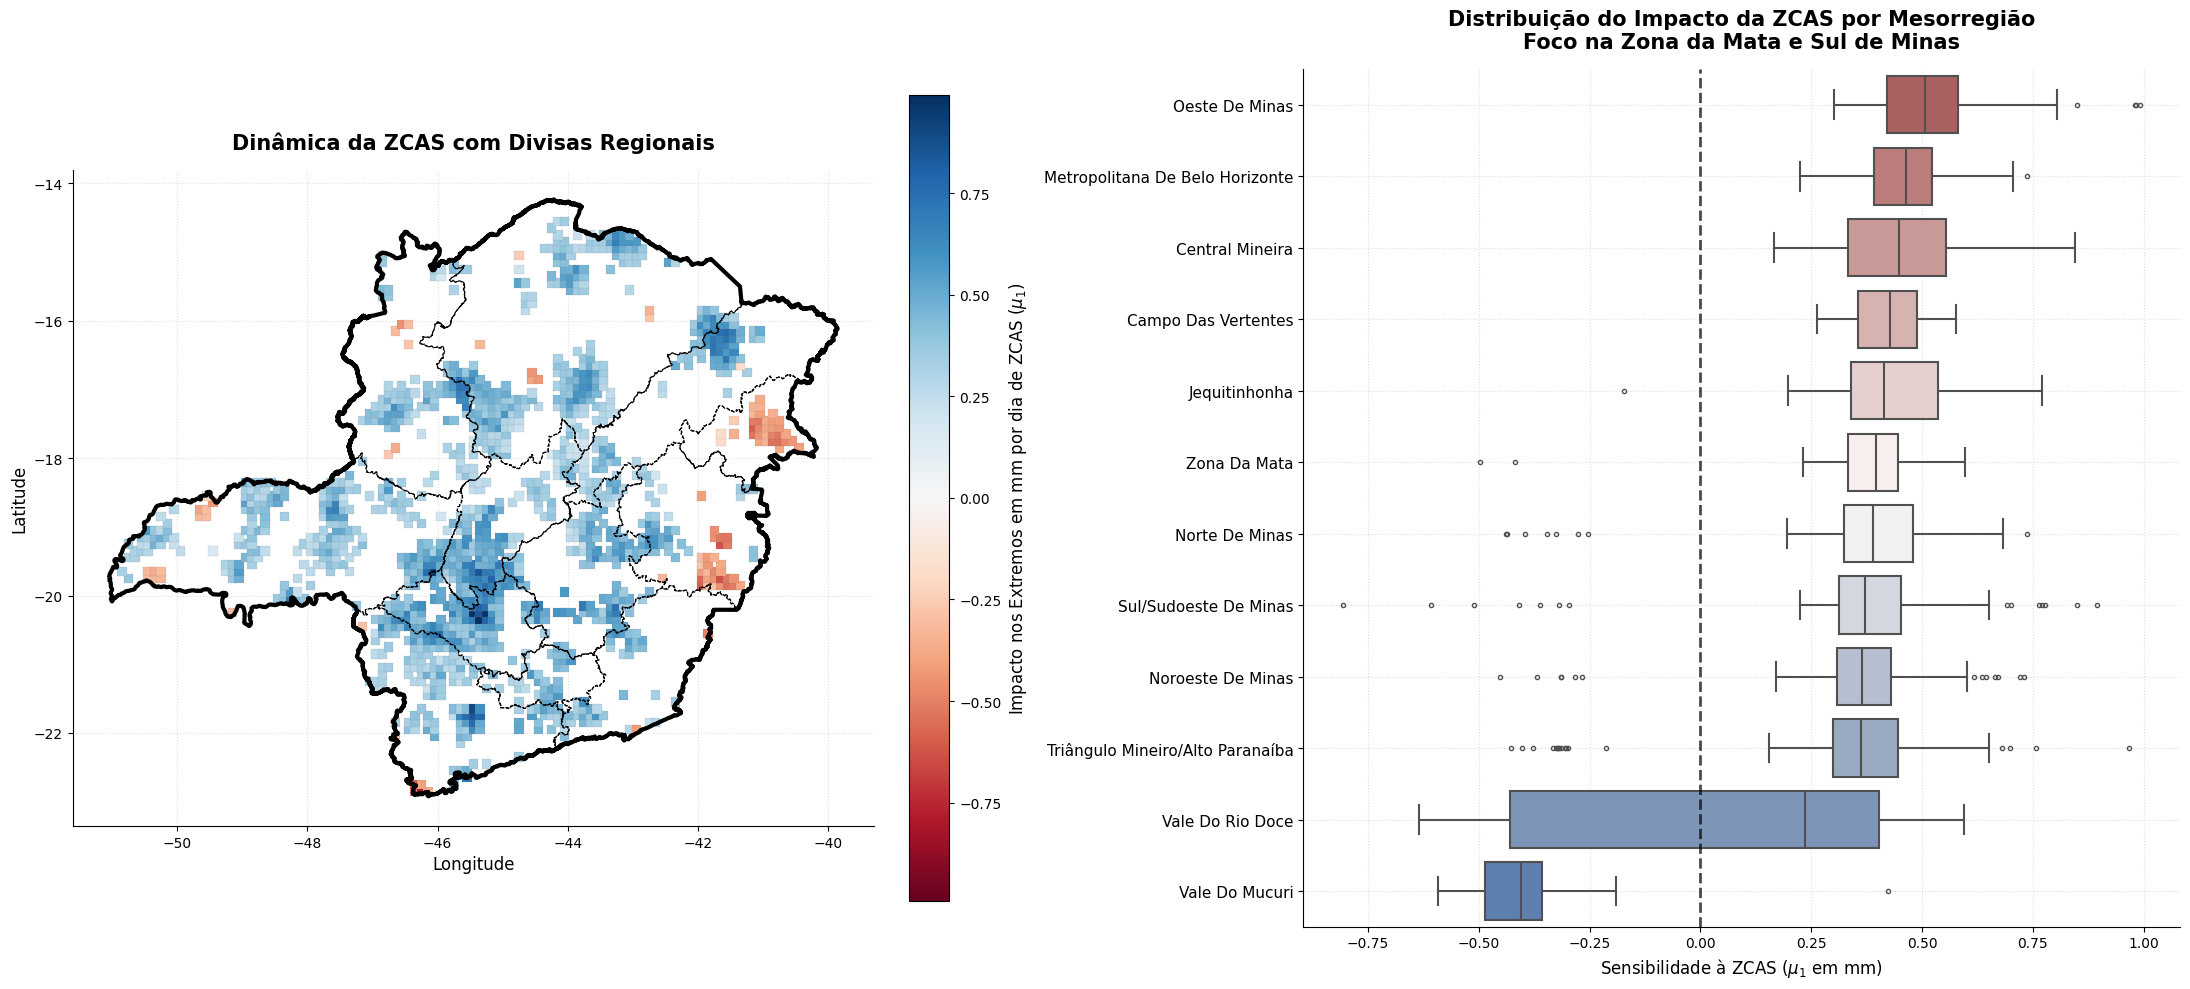


📊 MEDIANAS DO IMPACTO DA ZCAS POR REGIÃO:


,Nº Pixels Validados,Mediana do Impacto (mm/dia),Média do Impacto (mm/dia)
name_meso,,,
Oeste De Minas,112,0.506,0.523
Metropolitana De Belo Horizonte,120,0.464,0.459
Central Mineira,137,0.449,0.448
Campo Das Vertentes,30,0.427,0.427
Jequitinhonha,82,0.414,0.446
Zona Da Mata,44,0.397,0.370
Norte De Minas,262,0.390,0.389
Sul/Sudoeste De Minas,151,0.372,0.367
Noroeste De Minas,99,0.364,0.351


In [ ]:
# ==============================================================================
# CÉLULA 36: ANÁLISE REGIONAL DA ZCAS (BOXPLOT POR MESORREGIÃO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import geobr
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("1. Coletando os pixels afetados pela ZCAS na memória...")

# Extrai os dados da matriz rodada na Célula 35
pixels_validos_zcas = []
for i in range(len(lats)):
    for j in range(len(lons)):
        val_mu1 = matriz_mu1_zcas[i, j]
        if not np.isnan(val_mu1):
            pixels_validos_zcas.append({
                'lat': lats[i],
                'lon': lons[j],
                'Impacto_ZCAS': val_mu1
            })

if not pixels_validos_zcas:
    raise ValueError("⚠️ Nenhum pixel não-estacionário encontrado. Verifique a Célula 35.")

df_zcas = pd.DataFrame(pixels_validos_zcas)

print("2. Cruzando coordenadas com as mesorregiões do IBGE...")
try: meso_mg
except NameError: meso_mg = geobr.read_meso_region(code_meso="MG", year=2020)

# Transforma em GeoDataFrame
gdf_zcas = gpd.GeoDataFrame(df_zcas, geometry=[Point(xy) for xy in zip(df_zcas.lon, df_zcas.lat)], crs=meso_mg.crs)

# Spatial Join (Pega o nome da mesorregião onde o pixel caiu)
gdf_join_zcas = gpd.sjoin(gdf_zcas, meso_mg, how="inner", predicate="within")

# Ordena as regiões da maior para a menor mediana de impacto
ordem_regioes_zcas = gdf_join_zcas.groupby('name_meso')['Impacto_ZCAS'].median().sort_values(ascending=False).index

print("3. Desenhando o Painel Regional da ZCAS...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL REGIONAL (ZCAS)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- MAPA 1: IMPACTO COM DIVISAS REGIONAIS ---
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=3, zorder=4)
meso_mg.boundary.plot(ax=ax1, color='black', linewidth=0.8, linestyle='--', zorder=3)

limite = max(abs(gdf_join_zcas['Impacto_ZCAS'].min()), abs(gdf_join_zcas['Impacto_ZCAS'].max()))

scatter = ax1.scatter(gdf_join_zcas['lon'], gdf_join_zcas['lat'], c=gdf_join_zcas['Impacto_ZCAS'],
                      cmap='RdBu', marker='s', s=45, vmin=-limite, vmax=limite,
                      edgecolor='gray', linewidth=0.1, zorder=2)

cbar = plt.colorbar(scatter, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label(r'Impacto nos Extremos em mm por dia de ZCAS ($\mu_1$)', fontsize=12)

ax1.set_title("Dinâmica da ZCAS com Divisas Regionais", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)

# --- MAPA 2: BOXPLOT RANQUEADO POR REGIÃO ---
# Paleta focada no aumento de chuva (Blues) e redução (Reds)
sns.boxplot(data=gdf_join_zcas, y='name_meso', x='Impacto_ZCAS', order=ordem_regioes_zcas,
            ax=ax2, palette="vlag_r", fliersize=3, linewidth=1.5)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.7)

ax2.set_title("Distribuição do Impacto da ZCAS por Mesorregião\nFoco na Zona da Mata e Sul de Minas", fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel("")
ax2.set_xlabel(r"Sensibilidade à ZCAS ($\mu_1$ em mm)", fontsize=12)
ax2.tick_params(axis='y', labelsize=11)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# --- TABELA DE RESULTADOS PARA O ARTIGO ---
print("\n📊 MEDIANAS DO IMPACTO DA ZCAS POR REGIÃO:")
resumo_zcas = gdf_join_zcas.groupby('name_meso')['Impacto_ZCAS'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
resumo_zcas.columns = ['Nº Pixels Validados', 'Mediana do Impacto (mm/dia)', 'Média do Impacto (mm/dia)']
display(resumo_zcas.round(3))

In [ ]:
# ==============================================================================
# CÉLULA 37 (CORRIGIDA): O MODELO DEFINITIVO BIVARIADO (ONI + ZCAS) EM VIÇOSA
# ==============================================================================
import numpy as np
import pandas as pd
import xarray as xr
from scipy.optimize import minimize
from scipy.stats import genextreme
import warnings
warnings.filterwarnings('ignore')

caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"

print("1. Sincronizando as três engrenagens (Chuva, Oceano e Atmosfera)...")

# Coordenadas de Viçosa
lat_alvo = -20.75
lon_alvo = -42.87

# 1.1 Extrai a chuva do pixel e converte para DataFrame
try:
    pixel_chuva = ds_mg.sel(latitude=lat_alvo, longitude=lon_alvo, method='nearest')
except NameError:
    print("-> Recarregando ds_mg do Drive...")
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_mg = ds_br.sel(latitude=slice(-23.0, -14.0), longitude=slice(-51.5, -39.5))
    pixel_chuva = ds_mg.sel(latitude=lat_alvo, longitude=lon_alvo, method='nearest')

df_chuva = pixel_chuva['pr'].to_dataframe().reset_index()

# 1.2 VACINA ANTI-APAGÃO: Carrega o ONI e a ZCAS garantindo que não dê NameError
try:
    df_oni_base = df_oni.copy()
except NameError:
    print("-> Recarregando indice_oni_verao.csv do Drive...")
    df_oni_base = pd.read_csv(caminho_pasta + "indice_oni_verao.csv")

try:
    df_zcas_base = indice_zcas.copy()
except NameError:
    print("-> Recarregando indice_zcas_mg.csv do Drive...")
    df_zcas_base = pd.read_csv(caminho_pasta + "indice_zcas_mg.csv")

# 1.3 O Grande Intersect: Garante que só vamos usar anos que existam nas 3 bases
anos_comuns = set(df_chuva['ano']).intersection(set(df_oni_base['ano'])).intersection(set(df_zcas_base['ano']))
anos_comuns = np.sort(list(anos_comuns))

df_chuva_alinhada = df_chuva[df_chuva['ano'].isin(anos_comuns)].sort_values('ano')
df_oni_alinhado = df_oni_base[df_oni_base['ano'].isin(anos_comuns)].sort_values('ano')
df_zcas_alinhado = df_zcas_base[df_zcas_base['ano'].isin(anos_comuns)].sort_values('ano')

y = df_chuva_alinhada['pr'].values
x_oni = df_oni_alinhado['ONI_Verao'].values
x_zcas = df_zcas_alinhado['dias_ativos_zcas'].values

print(f" -> Bases alinhadas com sucesso! Temos {len(y)} anos de dados simultâneos.")

print("\n2. Ligando o Motor de Otimização Bivariado...")

def ajustar_gev_bivariada(y, x_oni, x_zcas):
    n = len(y)

    # Modelo 0 (Estacionário) para ancorar o chute inicial
    res0 = minimize(lambda p: (1e10 if p[1] <= 0 else -np.sum(genextreme.logpdf(y, -p[2], loc=p[0], scale=p[1]))),
                    [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')

    mu_base, sigma_base, xi_base = res0.x
    bic_m0 = 3 * np.log(n) + 2 * res0.fun

    # Modelo Bivariado (5 parâmetros)
    def nll_bivariado(p):
        mu0, mu_oni, mu_zcas, sigma, xi = p
        if sigma <= 0: return 1e10

        # A Equação Mestra
        mu_t = mu0 + mu_oni * x_oni + mu_zcas * x_zcas

        try:
            ll = np.sum(genextreme.logpdf(y, -xi, loc=mu_t, scale=sigma))
            return -ll if np.isfinite(ll) else 1e10
        except:
            return 1e10

    # Chute Inicial aninhado robusto
    chute = [mu_base, 0.0, 0.0, sigma_base, xi_base]
    res_biv = minimize(nll_bivariado, chute, method='Nelder-Mead', options={'maxiter': 5000})

    if res_biv.success:
        bic_biv = 5 * np.log(n) + 2 * res_biv.fun
        return res_biv.x, bic_biv, bic_m0
    return None

resultado = ajustar_gev_bivariada(y, x_oni, x_zcas)

print("\n=========================================================")
print("🏆 RESULTADO OFICIAL DO MODELO MÚLTIPLO")
print("=========================================================")
if resultado:
    params, bic_biv, bic_m0 = resultado
    mu0, mu_oni, mu_zcas, sigma, xi = params

    print(f"BIC do Modelo Estacionário (M0): {bic_m0:.2f}")
    print(f"BIC do Modelo Bivariado (ONI+ZCAS): {bic_biv:.2f}")

    if bic_biv < bic_m0:
        print("\n -> CONCLUSÃO: A variabilidade climática EXPLICA os extremos! (BIC caiu)")
        print(f" -> Peso do El Niño (mu_1): {mu_oni:.3f} mm por unidade ONI")
        print(f" -> Peso da ZCAS (mu_2): {mu_zcas:.3f} mm por dia ativo")
    else:
        print("\n -> CONCLUSÃO: O crivo rigoroso do BIC preferiu o Modelo Estacionário.")
        print("    A penalização por usar 5 parâmetros foi muito alta para o tamanho da amostra.")
        print(f"    Valores calculados apenas para conferência -> mu_oni: {mu_oni:.3f} | mu_zcas: {mu_zcas:.3f}")
else:
    print("O motor não conseguiu convergir para estes dados.")

1. Sincronizando as três engrenagens (Chuva, Oceano e Atmosfera)...
 -> Bases alinhadas com sucesso! Temos 35 anos de dados simultâneos.

2. Ligando o Motor de Otimização Bivariado...

🏆 RESULTADO OFICIAL DO MODELO MÚLTIPLO
BIC do Modelo Estacionário (M0): 302.05
BIC do Modelo Bivariado (ONI+ZCAS): 304.79

 -> CONCLUSÃO: O crivo rigoroso do BIC preferiu o Modelo Estacionário.
    A penalização por usar 5 parâmetros foi muito alta para o tamanho da amostra.
    Valores calculados apenas para conferência -> mu_oni: -2.498 | mu_zcas: 0.445


1. Preparando o Tribunal Multicritério na Zona da Mata...
2. Ligando a Execução Paralela com Votação...


Votação Múltipla GEV:   0%|          | 0/312 [00:00<?, ?it/s]


3. Votação Encerrada! Desenhando o Mapa de Consenso...


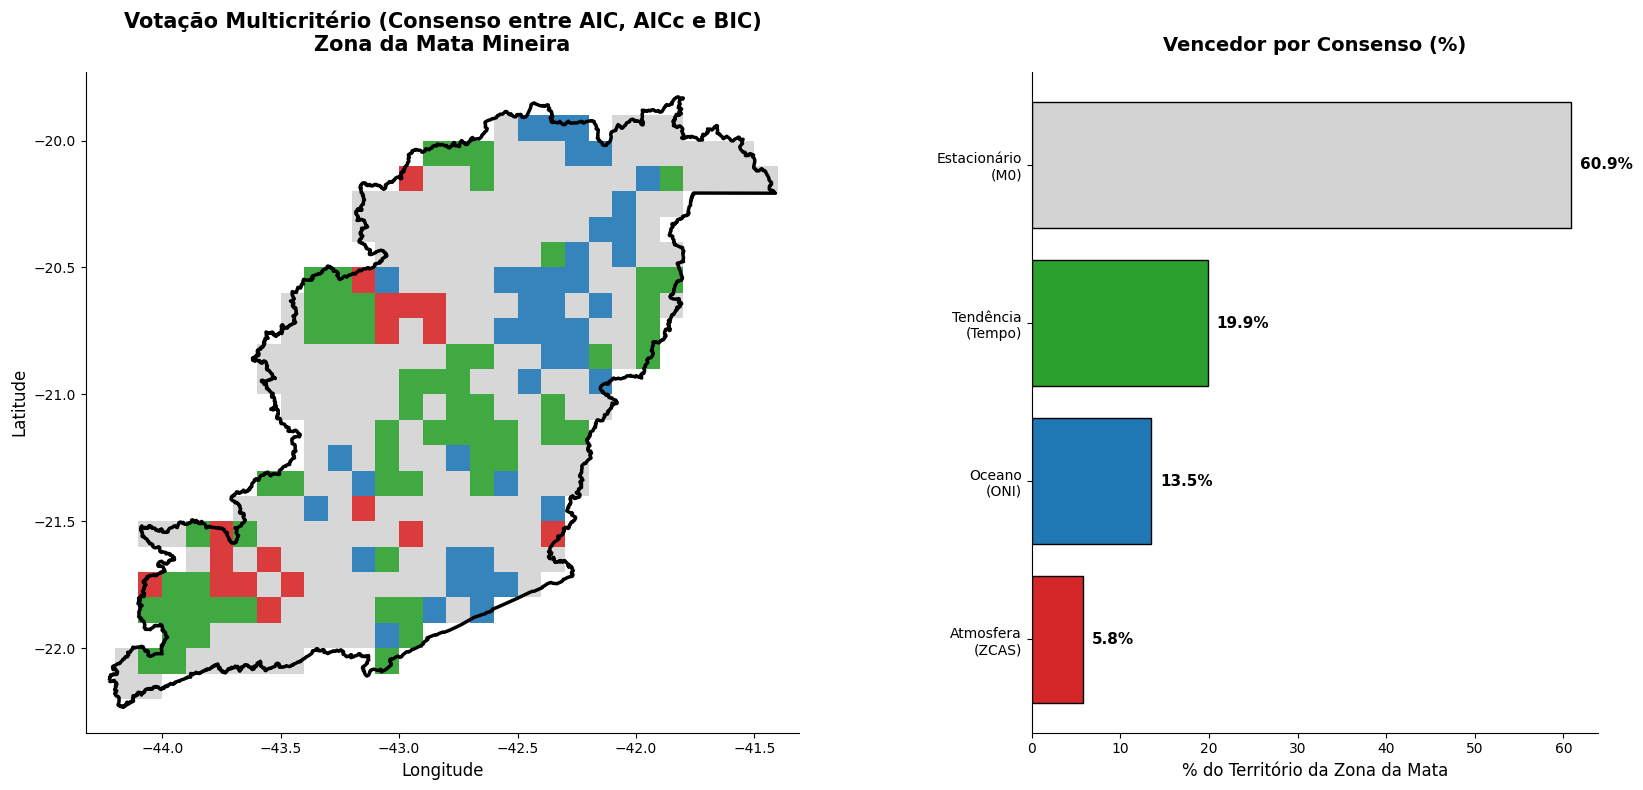

In [ ]:
# ==============================================================================
# CÉLULA 41: TRIBUNAL MULTICRITÉRIO (AIC, AICc, BIC) NA ZONA DA MATA
# ==============================================================================
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import minimize
from scipy.stats import genextreme
from collections import Counter
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("1. Preparando o Tribunal Multicritério na Zona da Mata...")

def calcular_criterios(n, k, nll):
    """Calcula a trinca de critérios de informação."""
    if not np.isfinite(nll) or nll == 1e10:
        return np.inf, np.inf, np.inf

    aic = 2 * k + 2 * nll
    # Proteção contra divisão por zero no AICc
    if (n - k - 1) > 0:
        aicc = aic + (2 * k * (k + 1)) / (n - k - 1)
    else:
        aicc = np.inf
    bic = k * np.log(n) + 2 * nll

    return aic, aicc, bic

def ajustar_competicao_tribunal(y, t, oni, zcas):
    n = len(y)

    # NLL base
    def nll(p, covar):
        mu0, mu1, sigma, xi = p
        if sigma <= 0: return 1e10
        try:
            ll = np.sum(genextreme.logpdf(y, -xi, loc=(mu0 + mu1 * covar), scale=sigma))
            return -ll if np.isfinite(ll) else 1e10
        except: return 1e10

    # 1. M0 (Estacionário) - 3 parâmetros
    res0 = minimize(lambda p: (1e10 if p[1] <= 0 else -np.sum(genextreme.logpdf(y, -p[2], loc=p[0], scale=p[1]))),
                    [np.mean(y), np.std(y), 0.1], method='Nelder-Mead')
    aic_0, aicc_0, bic_0 = calcular_criterios(n, 3, res0.fun)

    chute = [res0.x[0], 0.0, res0.x[1], res0.x[2]]

    # 2. MT (Tempo) - 4 parâmetros
    res_t = minimize(nll, chute, args=(t,), method='Nelder-Mead')
    aic_t, aicc_t, bic_t = calcular_criterios(n, 4, res_t.fun if res_t.success else np.inf)

    # 3. MONI (Oceano) - 4 parâmetros
    res_oni = minimize(nll, chute, args=(oni,), method='Nelder-Mead')
    aic_oni, aicc_oni, bic_oni = calcular_criterios(n, 4, res_oni.fun if res_oni.success else np.inf)

    # 4. MZCAS (Atmosfera) - 4 parâmetros
    res_zcas = minimize(nll, chute, args=(zcas,), method='Nelder-Mead')
    aic_zcas, aicc_zcas, bic_zcas = calcular_criterios(n, 4, res_zcas.fun if res_zcas.success else np.inf)

    # Coleta de votos
    votos_aic = np.argmin([aic_0, aic_t, aic_oni, aic_zcas])
    votos_aicc = np.argmin([aicc_0, aicc_t, aicc_oni, aicc_zcas])
    votos_bic = np.argmin([bic_0, bic_t, bic_oni, bic_zcas])

    # O Voto Final: A lista coloca o BIC em primeiro lugar.
    # Assim, no raríssimo caso de empate triplo (ex: 1 voto pra MT, 1 pra MONI, 1 pra MZCAS),
    # o Counter().most_common() resolve o empate mantendo o primeiro elemento encontrado (o BIC).
    urna = [votos_bic, votos_aicc, votos_aic]
    vencedor = Counter(urna).most_common(1)[0][0]

    return vencedor

print("2. Ligando a Execução Paralela com Votação...")
resultados_tribunal = Parallel(n_jobs=-1)(
    delayed(lambda idx: (idx[0], idx[1], ajustar_competicao_tribunal(idx[2], t_anos, x_oni, x_zcas)))(tarefa)
    for tarefa in tqdm(tarefas_zm, desc="Votação Múltipla GEV")
)

# Remontando os Mapas e Contagem
matriz_vencedores_trib = np.full((len(lats_zm), len(lons_zm)), np.nan)
contagem_trib = {0: 0, 1: 0, 2: 0, 3: 0}

for i, j, vencedor in resultados_tribunal:
    matriz_vencedores_trib[i, j] = vencedor
    contagem_trib[vencedor] += 1

print("\n3. Votação Encerrada! Desenhando o Mapa de Consenso...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL DO TRIBUNAL
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 8))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2)
ax2 = plt.subplot2grid((1, 3), (0, 2))

cores = ['#d3d3d3', '#2ca02c', '#1f77b4', '#d62728']
cmap_torneio = ListedColormap(cores)
nomes_modelos = ['Estacionário\n(M0)', 'Tendência\n(Tempo)', 'Oceano\n(ONI)', 'Atmosfera\n(ZCAS)']

lon_mesh, lat_mesh = np.meshgrid(lons_zm, lats_zm)
im = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores_trib, cmap=cmap_torneio, vmin=-0.5, vmax=3.5, shading='nearest', alpha=0.9)
zm_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5)

ax1.set_title("Votação Multicritério (Consenso entre AIC, AICc e BIC)\nZona da Mata Mineira", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.set_xlim(minx - 0.1, maxx + 0.1)
ax1.set_ylim(miny - 0.1, maxy + 0.1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

total_pixels = sum(contagem_trib.values())
perc_vencedores = [(contagem_trib[k] / total_pixels) * 100 for k in range(4)]

bars = ax2.barh(nomes_modelos[::-1], perc_vencedores[::-1], color=cores[::-1], edgecolor='black')
ax2.set_title("Vencedor por Consenso (%)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("% do Território da Zona da Mata", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

1. Isolando o ringue: Mesorregião do Sul/Sudoeste de Minas...
2. Alinhando os Vetores (Chuva, Tempo, ONI, ZCAS)...
3. Filtrando Pixels Internos e Ligando o Tribunal Estatístico...
 -> Total de pixels válidos no Sul de Minas: 433


Votação GEV - Sul de Minas:   0%|          | 0/433 [00:00<?, ?it/s]


4. Votação Encerrada! Desenhando o Painel de Diagnóstico do Sul de Minas...


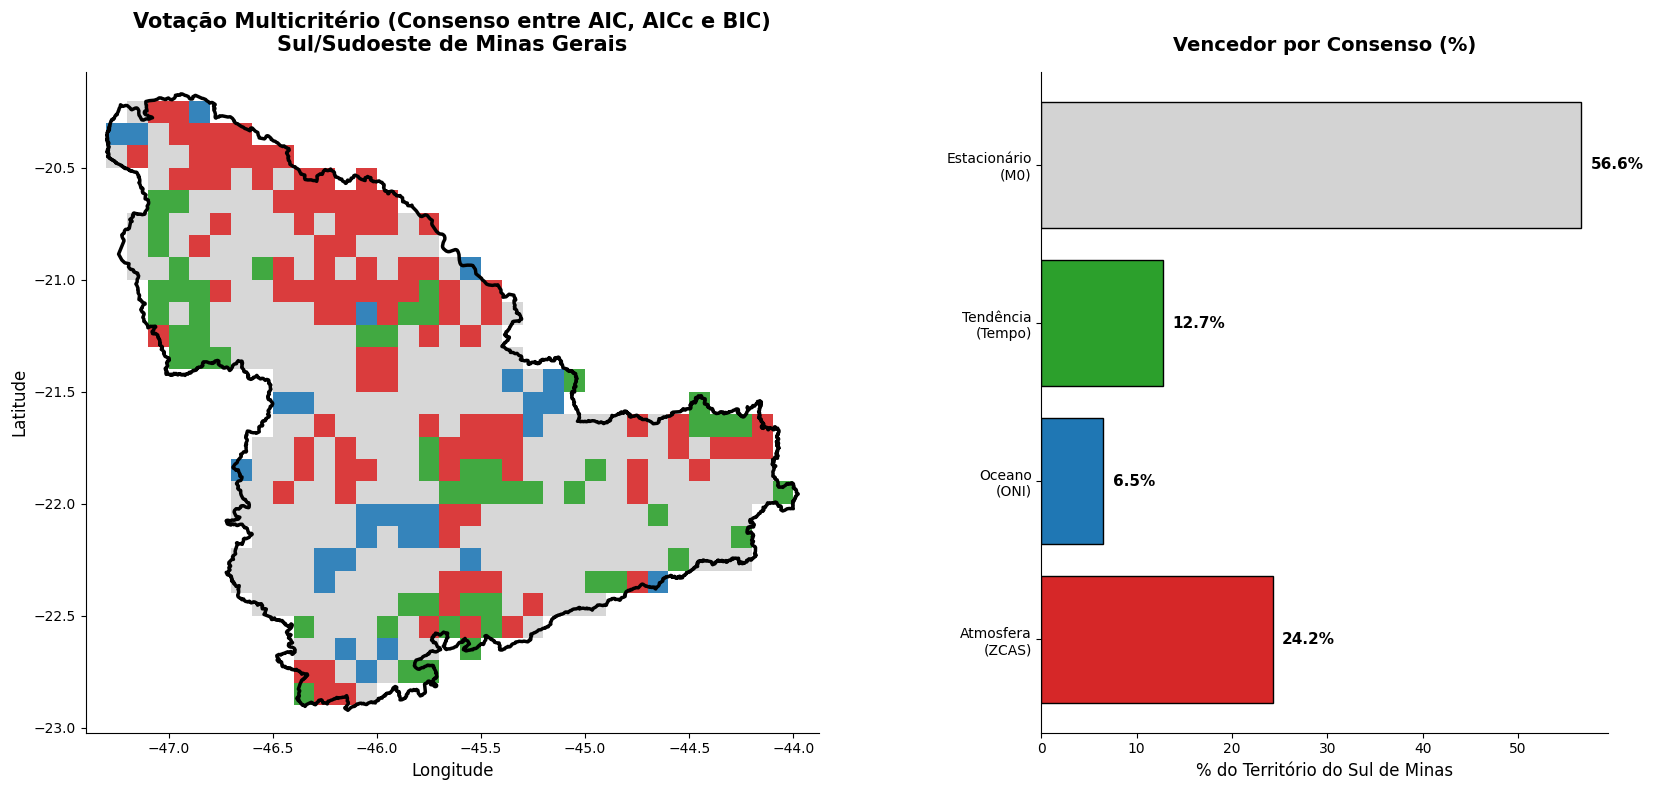

In [ ]:
# ==============================================================================
# CÉLULA 42: TRIBUNAL MULTICRITÉRIO (AIC, AICc, BIC) NO SUL DE MINAS
# ==============================================================================
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import minimize
from scipy.stats import genextreme
from collections import Counter
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("1. Isolando o ringue: Mesorregião do Sul/Sudoeste de Minas...")

try: meso_mg
except NameError:
    import geobr
    meso_mg = geobr.read_meso_region(code_meso="MG", year=2020)

# Extrai o polígono do Sul de Minas
sul_mg = meso_mg[meso_mg['name_meso'] == 'Sul/Sudoeste De Minas']
geom_sul = sul_mg.geometry.iloc[0]
minx, miny, maxx, maxy = geom_sul.bounds

# Recorta a matriz frouxamente para economizar RAM
try:
    ds_sul_box = ds_mg.sel(longitude=slice(minx - 0.1, maxx + 0.1), latitude=slice(miny - 0.1, maxy + 0.1))
except NameError:
    # Caso o Colab tenha limpado a RAM
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_sul_box = ds_br.sel(longitude=slice(minx - 0.1, maxx + 0.1), latitude=slice(maxy + 0.1, miny - 0.1))

lats_sul = ds_sul_box.latitude.values
lons_sul = ds_sul_box.longitude.values

print("2. Alinhando os Vetores (Chuva, Tempo, ONI, ZCAS)...")
anos_chuva = ds_sul_box['ano'].values
anos_comuns = set(anos_chuva).intersection(set(df_oni_base['ano'])).intersection(set(df_zcas_base['ano']))
anos_comuns = np.sort(list(anos_comuns))

ds_sul_box = ds_sul_box.sel(ano=anos_comuns)
chuva_matriz_sul = ds_sul_box['pr'].values

# Vetores de Covariáveis
x_oni = df_oni_base[df_oni_base['ano'].isin(anos_comuns)].sort_values('ano')['ONI_Verao'].values
x_zcas = df_zcas_base[df_zcas_base['ano'].isin(anos_comuns)].sort_values('ano')['dias_ativos_zcas'].values
t_anos = np.arange(1, len(anos_comuns) + 1)

print("3. Filtrando Pixels Internos e Ligando o Tribunal Estatístico...")

# Filtra pixels e Roda Paralelo
tarefas_sul = []
for i in range(len(lats_sul)):
    for j in range(len(lons_sul)):
        if Point(lons_sul[j], lats_sul[i]).within(geom_sul):
            serie = chuva_matriz_sul[:, i, j]
            if not np.isnan(serie).all():
                tarefas_sul.append((i, j, serie))

print(f" -> Total de pixels válidos no Sul de Minas: {len(tarefas_sul)}")

# Usa a função de votação multicritério que já está na memória (da célula 41)
resultados_sul = Parallel(n_jobs=-1)(
    delayed(lambda idx: (idx[0], idx[1], ajustar_competicao_tribunal(idx[2], t_anos, x_oni, x_zcas)))(tarefa)
    for tarefa in tqdm(tarefas_sul, desc="Votação GEV - Sul de Minas")
)

# Remontando o mapa
matriz_vencedores_sul = np.full((len(lats_sul), len(lons_sul)), np.nan)
contagem_sul = {0: 0, 1: 0, 2: 0, 3: 0}

for i, j, vencedor in resultados_sul:
    matriz_vencedores_sul[i, j] = vencedor
    contagem_sul[vencedor] += 1

print("\n4. Votação Encerrada! Desenhando o Painel de Diagnóstico do Sul de Minas...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL DO TRIBUNAL (SUL DE MINAS)
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 8))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2)
ax2 = plt.subplot2grid((1, 3), (0, 2))

cores = ['#d3d3d3', '#2ca02c', '#1f77b4', '#d62728']
cmap_torneio = ListedColormap(cores)
nomes_modelos = ['Estacionário\n(M0)', 'Tendência\n(Tempo)', 'Oceano\n(ONI)', 'Atmosfera\n(ZCAS)']

lon_mesh, lat_mesh = np.meshgrid(lons_sul, lats_sul)
im = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores_sul, cmap=cmap_torneio, vmin=-0.5, vmax=3.5, shading='nearest', alpha=0.9)
sul_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5)

ax1.set_title("Votação Multicritério (Consenso entre AIC, AICc e BIC)\nSul/Sudoeste de Minas Gerais", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.set_xlim(minx - 0.1, maxx + 0.1)
ax1.set_ylim(miny - 0.1, maxy + 0.1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

total_pixels = sum(contagem_sul.values())
perc_vencedores = [(contagem_sul[k] / total_pixels) * 100 for k in range(4)]

bars = ax2.barh(nomes_modelos[::-1], perc_vencedores[::-1], color=cores[::-1], edgecolor='black')
ax2.set_title("Vencedor por Consenso (%)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("% do Território do Sul de Minas", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

1. Carregando o mapa completo de Minas Gerais...
2. Sincronizando o relógio geológico (Chuva, Tempo, ONI, ZCAS)...
3. Filtrando a malha e iniciando o processamento pesado...
 -> Total de pixels válidos em MG: 5020. Segura o tranco!


Varredura Estadual GEV:   0%|          | 0/5020 [00:00<?, ?it/s]


4. Cálculos finalizados! Renderizando o mapa definitivo...


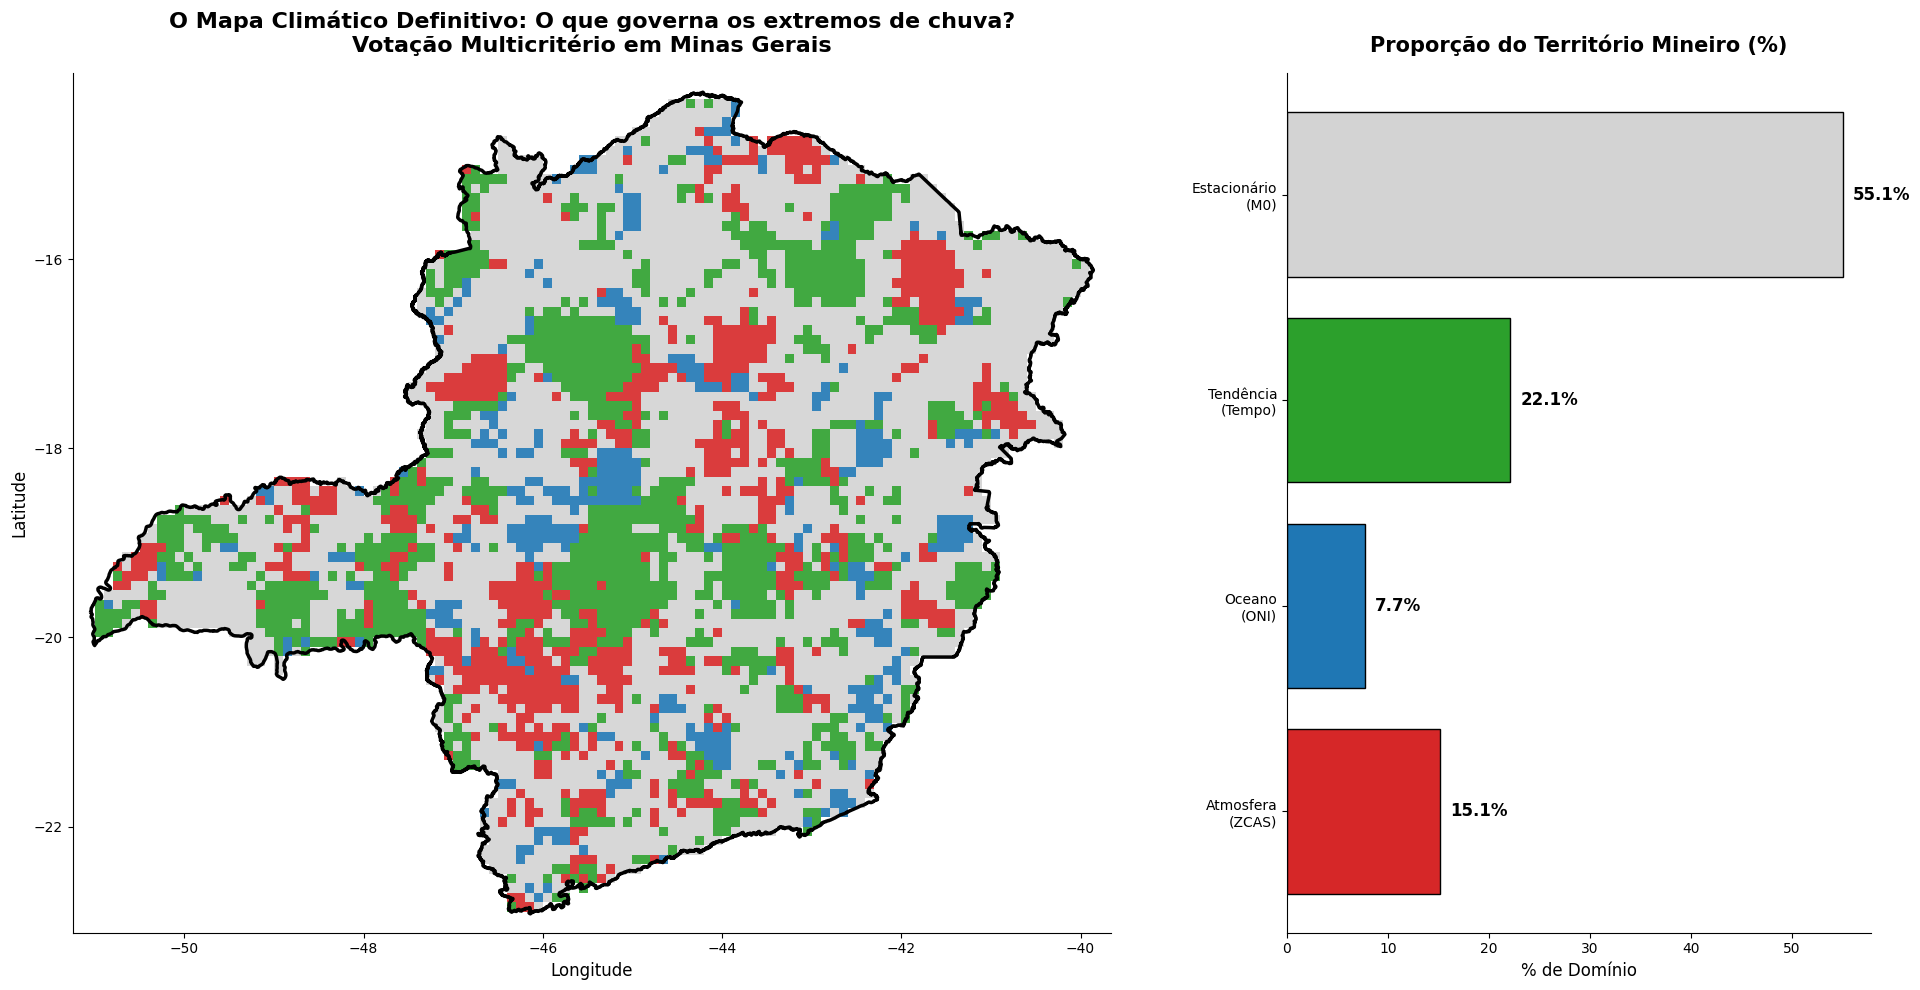

In [ ]:
# ==============================================================================
#   O GRANDE TRIBUNAL ESTATÍSTICO DE MINAS GERAIS (TEMPO vs ONI vs ZCAS)
# ==============================================================================
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import minimize
from scipy.stats import genextreme
from collections import Counter
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("1. Carregando o mapa completo de Minas Gerais...")

try: estado_mg
except NameError:
    import geobr
    estado_mg = geobr.read_state(code_state="MG", year=2020)

# Une todas as geometrias do estado (caso haja ilhas ou enclaves) para o filtro exato
geom_mg = estado_mg.geometry.unary_union
minx, miny, maxx, maxy = geom_mg.bounds

# Puxa a matriz de chuva do estado (que já definimos lá atrás)
try:
    ds_mg_analise = ds_mg
except NameError:
    # Caso a memória tenha limpado
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_mg_analise = ds_br.sel(longitude=slice(-51.5, -39.5), latitude=slice(-23.0, -14.0))

lats_mg = ds_mg_analise.latitude.values
lons_mg = ds_mg_analise.longitude.values

print("2. Sincronizando o relógio geológico (Chuva, Tempo, ONI, ZCAS)...")
anos_chuva = ds_mg_analise['ano'].values
anos_comuns = set(anos_chuva).intersection(set(df_oni_base['ano'])).intersection(set(df_zcas_base['ano']))
anos_comuns = np.sort(list(anos_comuns))

ds_mg_analise = ds_mg_analise.sel(ano=anos_comuns)
chuva_matriz_mg = ds_mg_analise['pr'].values

x_oni = df_oni_base[df_oni_base['ano'].isin(anos_comuns)].sort_values('ano')['ONI_Verao'].values
x_zcas = df_zcas_base[df_zcas_base['ano'].isin(anos_comuns)].sort_values('ano')['dias_ativos_zcas'].values
t_anos = np.arange(1, len(anos_comuns) + 1)

print("3. Filtrando a malha e iniciando o processamento pesado...")

tarefas_mg = []
for i in range(len(lats_mg)):
    for j in range(len(lons_mg)):
        # Verifica se a coordenada está fisicamente dentro de MG
        if Point(lons_mg[j], lats_mg[i]).within(geom_mg):
            serie = chuva_matriz_mg[:, i, j]
            # Descarta pixels inteiramente nulos
            if not np.isnan(serie).all():
                tarefas_mg.append((i, j, serie))

print(f" -> Total de pixels válidos em MG: {len(tarefas_mg)}. Segura o tranco!")

# A função de votação (ajustar_competicao_tribunal) já está na memória da Célula 41
resultados_mg = Parallel(n_jobs=-1)(
    delayed(lambda idx: (idx[0], idx[1], ajustar_competicao_tribunal(idx[2], t_anos, x_oni, x_zcas)))(tarefa)
    for tarefa in tqdm(tarefas_mg, desc="Varredura Estadual GEV")
)

# Remontando o quebra-cabeça gigante
matriz_vencedores_mg = np.full((len(lats_mg), len(lons_mg)), np.nan)
contagem_mg = {0: 0, 1: 0, 2: 0, 3: 0}

for i, j, vencedor in resultados_mg:
    matriz_vencedores_mg[i, j] = vencedor
    contagem_mg[vencedor] += 1

print("\n4. Cálculos finalizados! Renderizando o mapa definitivo...")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL DEFINITIVO - MINAS GERAIS
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 10))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2)
ax2 = plt.subplot2grid((1, 3), (0, 2))

cores = ['#d3d3d3', '#2ca02c', '#1f77b4', '#d62728']
cmap_torneio = ListedColormap(cores)
nomes_modelos = ['Estacionário\n(M0)', 'Tendência\n(Tempo)', 'Oceano\n(ONI)', 'Atmosfera\n(ZCAS)']

lon_mesh, lat_mesh = np.meshgrid(lons_mg, lats_mg)
im = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_vencedores_mg, cmap=cmap_torneio, vmin=-0.5, vmax=3.5, shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5)

ax1.set_title("O Mapa Climático Definitivo: O que governa os extremos de chuva?\nVotação Multicritério em Minas Gerais", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.set_xlim(minx - 0.2, maxx + 0.2)
ax1.set_ylim(miny - 0.2, maxy + 0.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

total_pixels = sum(contagem_mg.values())
perc_vencedores = [(contagem_mg[k] / total_pixels) * 100 for k in range(4)]

bars = ax2.barh(nomes_modelos[::-1], perc_vencedores[::-1], color=cores[::-1], edgecolor='black')
ax2.set_title("Proporção do Território Mineiro (%)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("% de Domínio", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
             va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

\section{Metodologia}

\subsection{Modelagem de Extremos Não-Estacionários via GEV}

Para a modelagem dos eventos extremos de precipitação diária anual no estado de Minas Gerais, utilizou-se a Distribuição Geral de Valores Extremos (GEV). A função de distribuição acumulada da GEV é dada por:

\begin{equation}
F(y; \mu, \sigma, \xi) = \exp \left\{ - \left[ 1 + \xi \left( \frac{y - \mu}{\sigma} \right) \right]_{+}^{-1/\xi} \right\}
\end{equation}

onde $\mu$ é o parâmetro de locação (indicando o centro da distribuição), $\sigma > 0$ é o parâmetro de escala (variabilidade) e $\xi$ é o parâmetro de forma, que determina o comportamento da cauda da distribuição.

A hipótese clássica de estacionariedade assume que as propriedades estatísticas dos extremos não mudam ao longo do tempo. Contudo, sob a influência de mudanças climáticas estruturais ou de modos de variabilidade de grande escala, essa premissa pode ser violada. Para investigar a dinâmica temporal e física dos extremos, o parâmetro de locação foi flexibilizado para incorporar covariáveis exógenas, assumindo a forma linear:

\begin{equation}
\mu_t = \mu_0 + \mu_1 X_t
\end{equation}

onde $X_t$ representa a força condutora no ano $t$. No presente estudo, a estimação de todos os parâmetros foi realizada via Método da Máxima Verossimilhança (MLE), utilizando uma inicialização aninhada (\textit{nested initialization}) baseada nos momentos da amostra para garantir a convergência numérica global dos algoritmos de otimização.

\subsection{O Torneio de Modelos e Hipóteses de Tendência}

Para diagnosticar a verdadeira origem das tendências observadas nas séries históricas de precipitação máxima, estruturou-se um "torneio de modelos", onde quatro formulações concorrentes competiram em cada pixel do território:

\begin{enumerate}
    \item \textbf{Modelo Estacionário ($M_0$):} Assume estabilidade climática pura, onde os extremos flutuam em torno de uma média constante.
    \begin{equation}
    \mu_t = \mu_0
    \end{equation}
    
    \item \textbf{Modelo de Tendência Temporal Pura ($M_{\text{Tempo}}$):} Assume uma variação linear contínua em função do tempo ($t = 1, 2, \dots, n$), funcionando como um \textit{proxy} para mudanças climáticas antropogênicas ou estruturais de longo prazo.
    \begin{equation}
    \mu_t = \mu_0 + \mu_1 \cdot t
    \end{equation}
    
    \item \textbf{Modelo de Forçante Oceânica ($M_{\text{ONI}}$):} Assume que a variabilidade dos extremos é governada pelas anomalias de grande escala de Temperatura da Superfície do Mar (TSM) no Pacífico Equatorial, utilizando o índice \textit{Oceanic Niño Index} (ONI) do trimestre de verão.
    \begin{equation}
    \mu_t = \mu_0 + \mu_1 \cdot \text{ONI}_t
    \end{equation}
    
    \item \textbf{Modelo de Forçante Atmosférica Regional ($M_{\text{ZCAS}}$):} Assume que a frequência de sistemas convectivos de escala regional dita o comportamento extremo local, utilizando o índice de dias ativos da Zona de Convergência do Atlântico Sul (ZCAS), derivado da Radiação de Onda Longa (ROL).
    \begin{equation}
    \mu_t = \mu_0 + \mu_1 \cdot \text{ZCAS}_t
    \end{equation}
\end{enumerate}

\subsection{Tribunal Multicritério de Seleção}

A seleção do modelo vencedor para cada localidade foi conduzida por meio de um sistema de consenso de voto majoritário entre três critérios de informação independentes: o Critério de Informação de Akaike (AIC), o Critério de Informação de Akaike Corrigido para Amostras Finitas (AICc) e o Critério de Informação Bayesiano (BIC). As formulações matemáticas utilizadas foram:

\begin{align}
AIC &= 2k + 2L \\
AICc &= AIC + \frac{2k(k+1)}{n - k - 1} \\
BIC &= k \ln(n) + 2L
\end{align}

onde $k$ representa o número de parâmetros estimados do modelo, $n$ é o tamanho da série temporal e $L$ é a log-verossimilhança negativa minimizada.

O modelo foi declarado vencedor se obtivesse a preferência em pelo menos dois dos três critérios avaliados. No caso de uma discordância tripla (um evento estocasticamente raro), o BIC foi adotado como critério de desempate devido ao seu rigor e penalização mais severa para a parcimônia do modelo, garantindo que a complexidade de um parâmetro não-estacionário extra ($\mu_1$) só seja aceita mediante forte evidência estatística.

In [ ]:
!pip install pymannkendall

1. Ligando o radar do Teste de Mann-Kendall para Minas Gerais...


Rodando Mann-Kendall:   0%|          | 0/5020 [00:00<?, ?it/s]

2. Cruzando os vereditos: GEV vs Mann-Kendall...

3. Desenhando o Mapa de Consenso Absoluto (Filtro de Significância)...


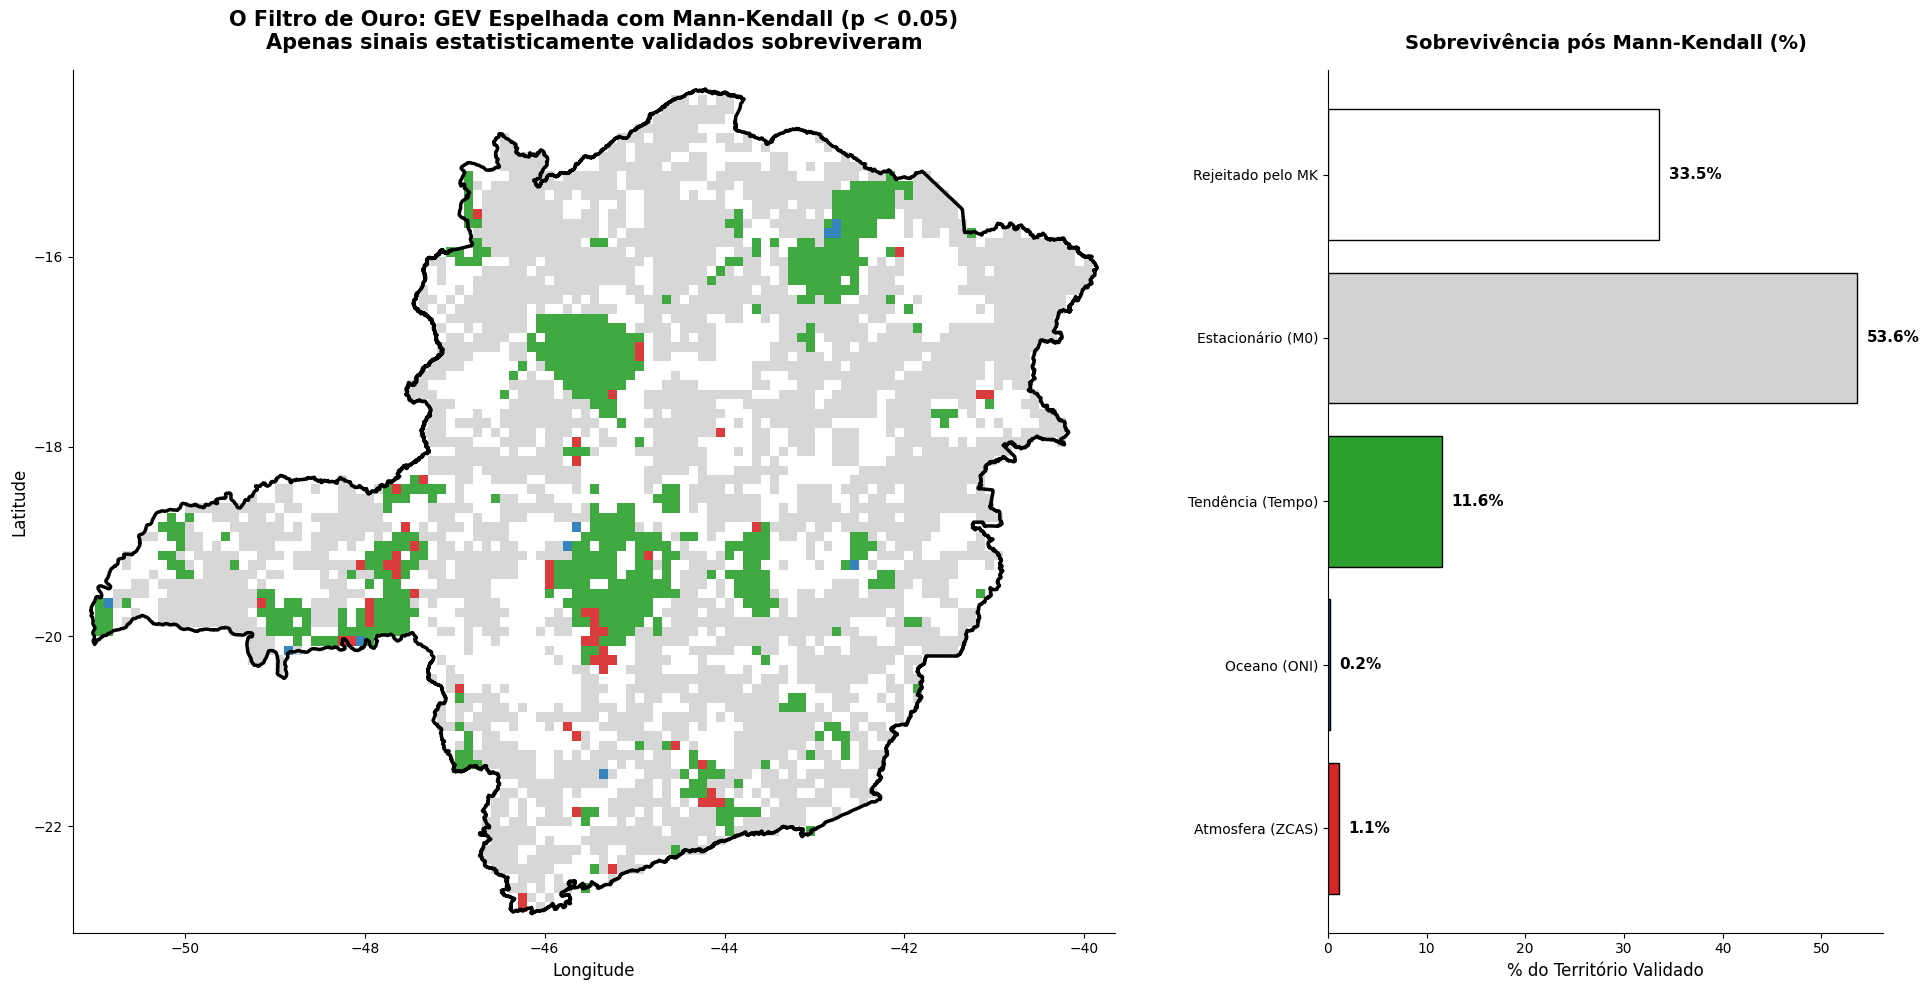

In [ ]:
# ==============================================================================
#          VALIDAÇÃO CRUZADA (GEV MULTICRITÉRIO vs MANN-KENDALL)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pymannkendall as mk
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("1. Ligando o radar do Teste de Mann-Kendall para Minas Gerais...")

# Função empacotadora para o Mann-Kendall
def aplicar_mann_kendall(i, j, serie):
    try:
        # O teste original busca tendências monótonas na série
        resultado_mk = mk.original_test(serie)
        # Retorna a coordenada, o p-valor e a direção (+1 subindo, -1 caindo, 0 sem tendência)
        tendencia_num = 1 if resultado_mk.trend == 'increasing' else (-1 if resultado_mk.trend == 'decreasing' else 0)
        return (i, j, resultado_mk.p, tendencia_num)
    except:
        return (i, j, np.nan, np.nan)

# Aproveitamos a lista de 'tarefas_mg' que já tem os pixels válidos de terra firme do estado
resultados_mk = Parallel(n_jobs=-1)(
    delayed(aplicar_mann_kendall)(i, j, serie)
    for i, j, serie in tqdm(tarefas_mg, desc="Rodando Mann-Kendall")
)

print("2. Cruzando os vereditos: GEV vs Mann-Kendall...")

matriz_mk_pvalor = np.full((len(lats_mg), len(lons_mg)), np.nan)
matriz_consenso_absoluto = np.full((len(lats_mg), len(lons_mg)), np.nan)
contagem_consenso = {0: 0, 1: 0, 2: 0, 3: 0, -1: 0} # -1 será para os 'Falsos Positivos'

# Nível de significância
alpha = 0.05

for i, j, p_valor, dir_tendencia in resultados_mk:
    matriz_mk_pvalor[i, j] = p_valor
    vencedor_gev = matriz_vencedores_mg[i, j]

    if np.isnan(vencedor_gev):
        continue

    # LÓGICA DE INTERSEÇÃO RIGOROSA:
    if vencedor_gev == 0:
        # GEV diz que é Estacionário.
        if p_valor > alpha:
            # MK concorda (não há tendência). Ponto para a Estacionariedade!
            matriz_consenso_absoluto[i, j] = 0
            contagem_consenso[0] += 1
        else:
            # Conflito: GEV achou estacionário, mas MK achou tendência oculta. (Marcamos como ruído/descarte)
            matriz_consenso_absoluto[i, j] = -1
            contagem_consenso[-1] += 1

    else:
        # GEV diz que Tempo(1), ONI(2) ou ZCAS(3) governam a série.
        if p_valor <= alpha:
            # MK concorda! A série realmente tem uma tendência subjacente forte.
            matriz_consenso_absoluto[i, j] = vencedor_gev
            contagem_consenso[vencedor_gev] += 1
        else:
            # Falso Positivo da GEV: O modelo achou covariável, mas o MK diz que é só ruído estatístico.
            matriz_consenso_absoluto[i, j] = -1
            contagem_consenso[-1] += 1

print("\n3. Desenhando o Mapa de Consenso Absoluto (Filtro de Significância)...")

# ------------------------------------------------------------------------------
# PLOTAGEM: O MAPA DE CONSENSO ABSOLUTO
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 10))
ax1 = plt.subplot2grid((1, 3), (0, 0), colspan=2)
ax2 = plt.subplot2grid((1, 3), (0, 2))

# Adicionamos a cor branca/vazia para representar os pixels rejeitados pelo Mann-Kendall (-1)
cores_consenso = ['#ffffff', '#d3d3d3', '#2ca02c', '#1f77b4', '#d62728']
cmap_consenso = ListedColormap(cores_consenso)
nomes_modelos = ['Rejeitado pelo MK', 'Estacionário (M0)', 'Tendência (Tempo)', 'Oceano (ONI)', 'Atmosfera (ZCAS)']

lon_mesh, lat_mesh = np.meshgrid(lons_mg, lats_mg)
# vmin e vmax ajustados para acomodar o -1
im = ax1.pcolormesh(lon_mesh, lat_mesh, matriz_consenso_absoluto, cmap=cmap_consenso, vmin=-1.5, vmax=3.5, shading='nearest', alpha=0.9)
estado_mg.boundary.plot(ax=ax1, color='black', linewidth=2.5)

ax1.set_title("O Filtro de Ouro: GEV Espelhada com Mann-Kendall (p < 0.05)\nApenas sinais estatisticamente validados sobreviveram", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Longitude", fontsize=12)
ax1.set_ylabel("Latitude", fontsize=12)
ax1.set_xlim(minx - 0.2, maxx + 0.2)
ax1.set_ylim(miny - 0.2, maxy + 0.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# GRÁFICO DE BARRAS DE CONSENSO
total_pixels_validos = sum(contagem_consenso.values())
perc_consenso = [(contagem_consenso[k] / total_pixels_validos) * 100 for k in [-1, 0, 1, 2, 3]]

bars = ax2.barh(nomes_modelos[::-1], perc_consenso[::-1], color=cores_consenso[::-1], edgecolor='black')
ax2.set_title("Sobrevivência pós Mann-Kendall (%)", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("% do Território Validado", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar in bars:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%',
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

1. Extraindo a série pura de máximas anuais de Viçosa...
 -> Série carregada! 65 anos de registros extremos contínuos.

2. Processando o domínio do tempo (ACF) e das frequências (Periodograma)...


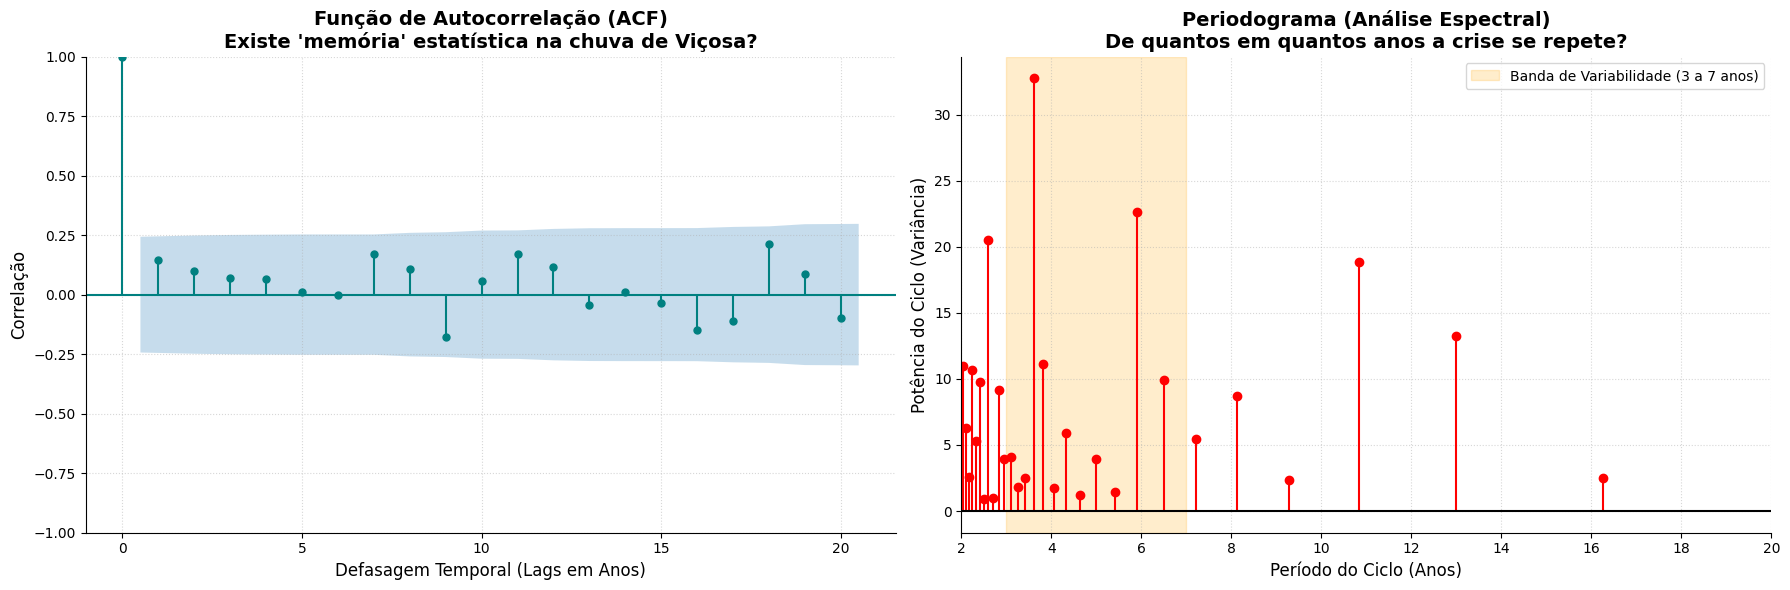

In [ ]:
# ==============================================================================
# CÉLULA 45: DIAGNÓSTICO DE CICLICIDADE (ACF E PERIODOGRAMA) - VIÇOSA
# ==============================================================================
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy.signal import periodogram
import warnings
warnings.filterwarnings('ignore')

print("1. Extraindo a série pura de máximas anuais de Viçosa...")

# Coordenadas de Viçosa
lat_alvo = -20.75
lon_alvo = -42.87

# Tenta puxar da memória, se o Colab tiver limpado, busca no Drive
try:
    pixel_chuva = ds_mg.sel(latitude=lat_alvo, longitude=lon_alvo, method='nearest')
except NameError:
    print("-> Recarregando ds_mg do Drive...")
    caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_mg = ds_br.sel(latitude=slice(-23.0, -14.0), longitude=slice(-51.5, -39.5))
    pixel_chuva = ds_mg.sel(latitude=lat_alvo, longitude=lon_alvo, method='nearest')

# Extrai o vetor de precipitação e remove NaNs
y_vicosa = pixel_chuva['pr'].dropna(dim='ano').values
anos = pixel_chuva['ano'].dropna(dim='ano').values

print(f" -> Série carregada! {len(y_vicosa)} anos de registros extremos contínuos.")
print("\n2. Processando o domínio do tempo (ACF) e das frequências (Periodograma)...")

# --- CÁLCULO DO PERIODOGRAMA ---
# fs = 1 amostra por ano.
# scaling = 'spectrum' para vermos a amplitude da variância em cada frequência.
frequencias, potencia = periodogram(y_vicosa, fs=1.0, scaling='spectrum')

# Removemos a frequência zero (média/tendência contínua) para focar nas oscilações
freq_validas = frequencias[1:]
pot_validas = potencia[1:]

# Converte Frequência (ciclos por ano) para Período (anos por ciclo)
periodos_anos = 1 / freq_validas

# ------------------------------------------------------------------------------
# PLOTAGEM DUPLA (ACF + ESPECTRO)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- GRÁFICO 1: AUTOCORRELAÇÃO (Memória da Série) ---
plot_acf(y_vicosa, ax=ax1, lags=20, alpha=0.05, color='teal', vlines_kwargs={'colors': 'teal'})
ax1.set_title("Função de Autocorrelação (ACF)\nExiste 'memória' estatística na chuva de Viçosa?", fontsize=14, fontweight='bold')
ax1.set_xlabel("Defasagem Temporal (Lags em Anos)", fontsize=12)
ax1.set_ylabel("Correlação", fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- GRÁFICO 2: PERIODOGRAMA (A Busca por Ciclos) ---
# Usamos stem (hastes) para destacar as bandas de potência
ax2.stem(periodos_anos, pot_validas, linefmt='r-', markerfmt='ro', basefmt='k-')

# Destaca a "Zona de Perigo" clássica de variabilidade climática (ex: El Niño 3 a 7 anos)
ax2.axvspan(3, 7, color='orange', alpha=0.2, label='Banda de Variabilidade (3 a 7 anos)')

ax2.set_title("Periodograma (Análise Espectral)\nDe quantos em quantos anos a crise se repete?", fontsize=14, fontweight='bold')
ax2.set_xlabel("Período do Ciclo (Anos)", fontsize=12)
ax2.set_ylabel("Potência do Ciclo (Variância)", fontsize=12)
ax2.set_xlim(2, 20) # Foca em ciclos de 2 a 20 anos
ax2.set_xticks(np.arange(2, 21, 2))
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1. Extraindo a série pura de máximas anuais de Uberlândia...
 -> Série carregada! 65 anos de registros contínuos no Triângulo Mineiro.

2. Ligando o Tribunal GEV (Estacionário vs Tempo)...
🏆 RESULTADO DO TRIBUNAL EM UBERLÂNDIA:
 -> BIC do Modelo Estacionário (M0): 539.43
 -> BIC do Modelo de Tempo (MT): 540.35

 -> CONCLUSÃO: O BIC preferiu o Modelo Estacionário. A tendência não é forte o suficiente.


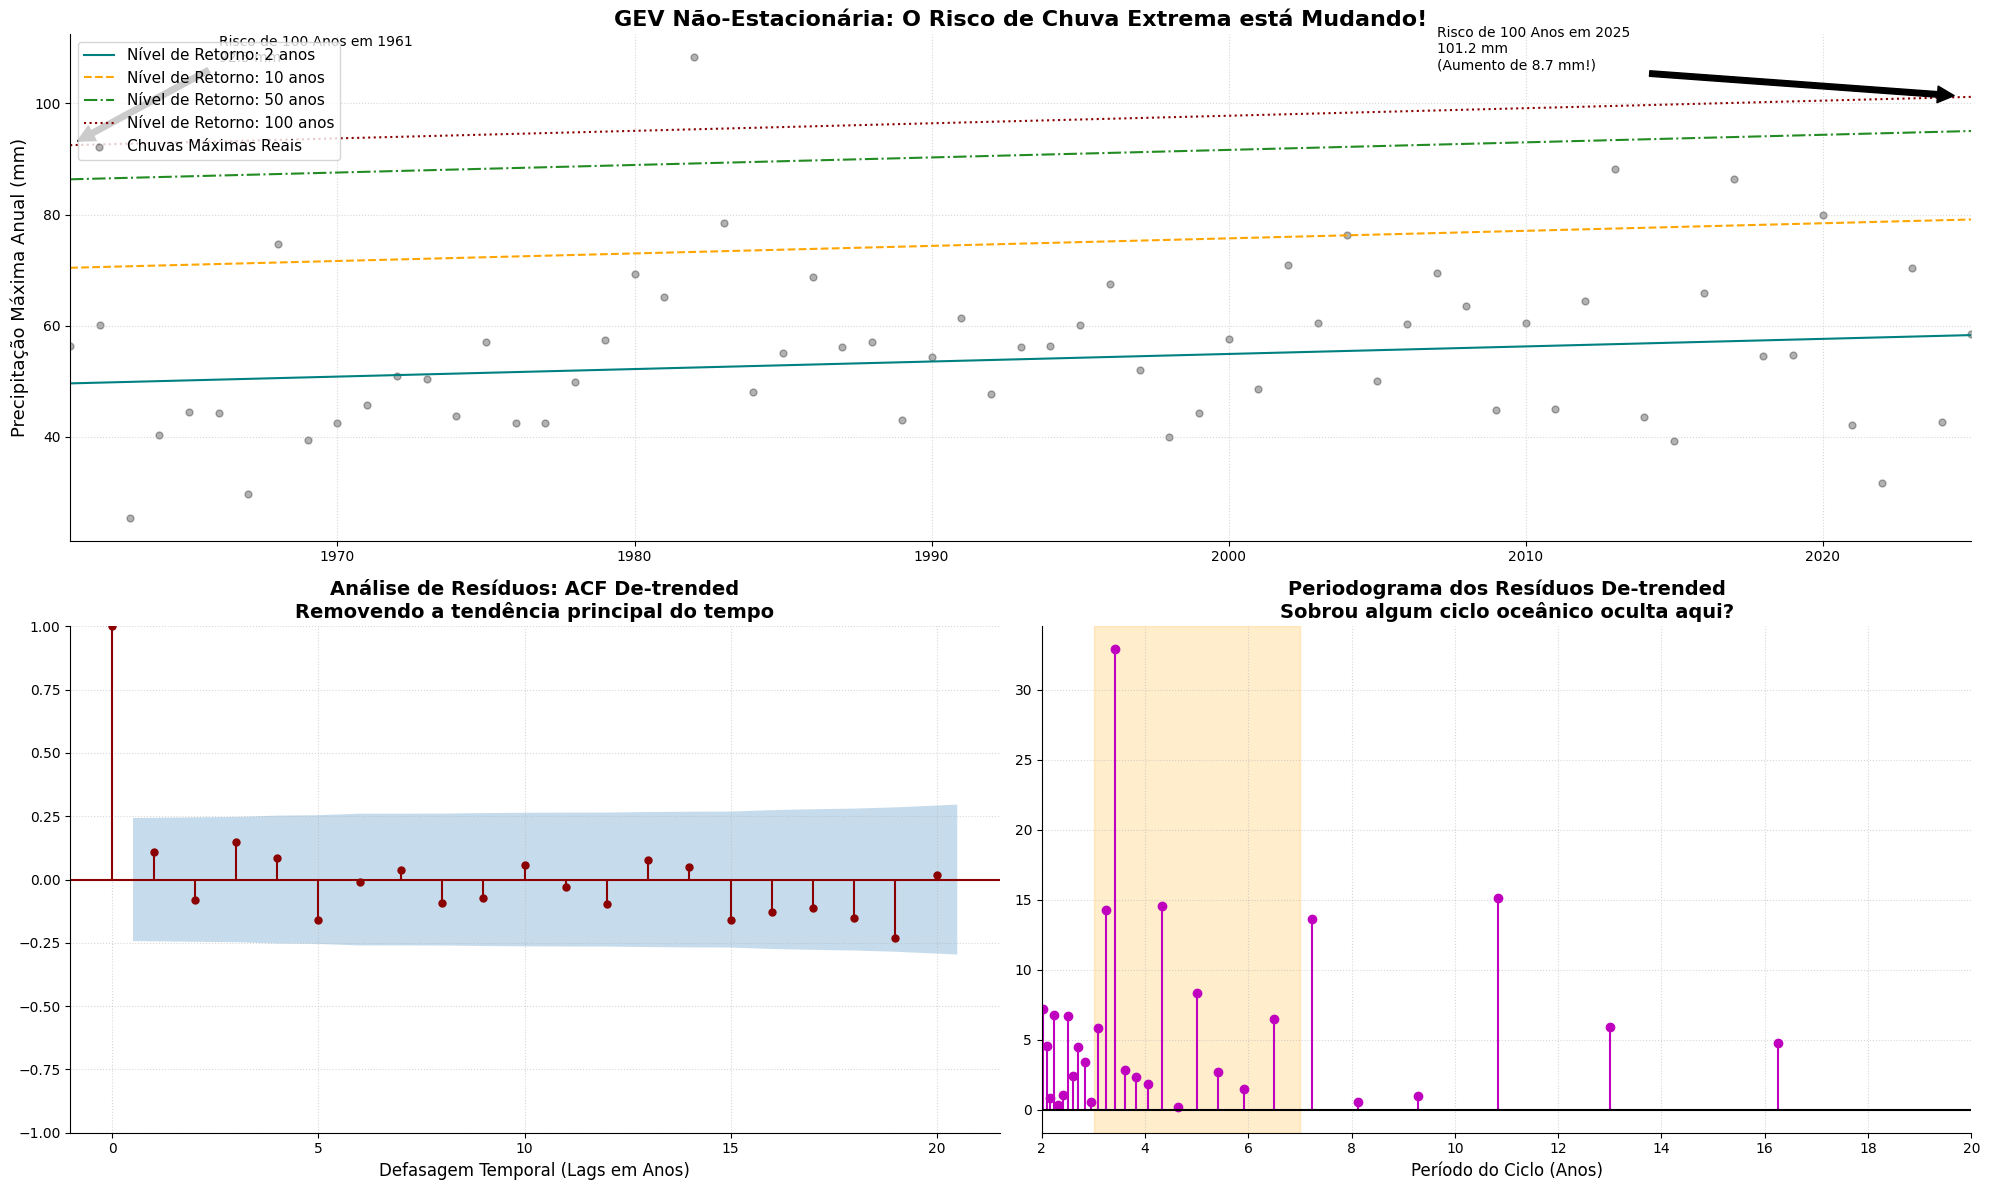

In [ ]:
# ==============================================================================
# CÉLULA 46: DIAGNÓSTICO DE NÃO-ESTACIONARIEDADE PURA (EXEMPLO: UBERLÂNDIA)
# ==============================================================================
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import genextreme
from statsmodels.graphics.tsaplots import plot_acf
from scipy.signal import periodogram
import warnings
warnings.filterwarnings('ignore')

print("1. Extraindo a série pura de máximas anuais de Uberlândia...")

# Coordenadas de Uberlândia (Triângulo Mineiro - Zona Verde do Mapa)
lat_uber = -18.91
lon_uber = -48.27

# Tenta puxar da memória, se o Colab tiver limpado, busca no Drive
try:
    pixel_uber = ds_mg.sel(latitude=lat_uber, longitude=lon_uber, method='nearest')
except NameError:
    print("-> Recarregando ds_mg do Drive...")
    caminho_pasta = "/content/drive/MyDrive/DOUTORADO/DOUTORADO/"
    ds_br = xr.open_dataset(caminho_pasta + "br_maximas_anuais_oni_1961_2025.nc")
    ds_mg = ds_br.sel(latitude=slice(-23.0, -14.0), longitude=slice(-51.5, -39.5))
    pixel_uber = ds_mg.sel(latitude=lat_uber, longitude=lon_uber, method='nearest')

# Extrai o vetor de precipitação e anos
y_uber = pixel_uber['pr'].dropna(dim='ano').values
anos_uber = pixel_uber['ano'].dropna(dim='ano').values
n = len(y_uber)
t_uber = np.arange(1, n + 1) # Vetor de tempo normalizado (t=1, 2, 3...)

print(f" -> Série carregada! {n} anos de registros contínuos no Triângulo Mineiro.")

print("\n2. Ligando o Tribunal GEV (Estacionário vs Tempo)...")

# --- MODELO 0 (ESTACIONÁRIO) ---
res0 = minimize(lambda p: (1e10 if p[1] <= 0 else -np.sum(genextreme.logpdf(y_uber, -p[2], loc=p[0], scale=p[1]))),
                [np.mean(y_uber), np.std(y_uber), 0.1], method='Nelder-Mead')
bic0 = 3 * np.log(n) + 2 * res0.fun
mu_base, sigma_base, xi_base = res0.x

# --- MODELO T (TENDÊNCIA TEMPORAL PURE) mu_t = mu0 + mu1 * t ---
def nll_tempo(p):
    mu0, mu1, sigma, xi = p
    if sigma <= 0: return 1e10
    mu_t = mu0 + mu1 * t_uber # A EQUAÇÃO MESTRA NÃO-ESTACIONÁRIA
    try:
        ll = np.sum(genextreme.logpdf(y_uber, -xi, loc=mu_t, scale=sigma))
        return -ll if np.isfinite(ll) else 1e10
    except: return 1e10

chute_t = [mu_base, 0.0, sigma_base, xi_base]
res_t = minimize(nll_tempo, chute_t, method='Nelder-Mead', options={'maxiter': 5000})
bic_t = 4 * np.log(n) + 2 * res_t.fun
mu0_f, mu1_f, sigma_f, xi_f = res_t.x

print("🏆 RESULTADO DO TRIBUNAL EM UBERLÂNDIA:")
print(f" -> BIC do Modelo Estacionário (M0): {bic0:.2f}")
print(f" -> BIC do Modelo de Tempo (MT): {bic_t:.2f}")

if bic_t < bic0:
    print(f"\n -> CONCLUSÃO: A MUDANÇA CLIMÁTICA FOI COMPROVADA! (BIC caiu)")
    print(f" -> Parâmetro mu_1 (Tendência): {mu1_f:.3f} mm por ano.")
    interpretacao = "aumentando" if mu1_f > 0 else "diminuindo"
    print(f" -> Interpretação: A média dos extremos está {interpretacao} {abs(mu1_f * n):.1f} mm nas últimas décadas.")
else:
    print("\n -> CONCLUSÃO: O BIC preferiu o Modelo Estacionário. A tendência não é forte o suficiente.")

# ------------------------------------------------------------------------------
# PLOTAGEM DO PAINEL DE DIAGNÓSTICO NÃO-ESTACIONÁRIO
# ------------------------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax2 = plt.subplot2grid((2, 2), (1, 0))
ax3 = plt.subplot2grid((2, 2), (1, 1))

# --- GRÁFICO 1: O RISCO EM MUDANÇA (Níveis de Retorno GEV) ---
mu_ts_model = mu0_f + mu1_f * t_uber # Calcula o mu para cada ano

# Calcula Níveis de Retorno (ex: 2, 10, 50, 100 anos)
periodos = [2, 10, 50, 100]
estilos = ['-', '--', '-.', ':']
cores_retorno = ['teal', 'orange', 'forestgreen', 'darkred']

for p, est, cor in zip(periodos, estilos, cores_retorno):
    # Genextreme probability is 1/Period
    probabilidade = 1.0 - (1.0 / p)
    # GEV ppf function returns the level for a given probability
    niveis = genextreme.ppf(probabilidade, -xi_f, loc=mu_ts_model, scale=sigma_f)
    ax1.plot(anos_uber, niveis, est, color=cor, label=f'Nível de Retorno: {p} anos')

# Plota as chuvas reais para referência
ax1.scatter(anos_uber, y_uber, color='black', alpha=0.3, s=25, label='Chuvas Máximas Reais')

ax1.set_title(r"GEV Não-Estacionária: O Risco de Chuva Extrema está Mudando!", fontsize=16, fontweight='bold')
ax1.set_ylabel("Precipitação Máxima Anual (mm)", fontsize=13)
ax1.legend(loc='upper left', frameon=True, fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.set_xlim(anos_uber.min(), anos_uber.max())
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Adiciona anotação do temporal de 100 anos no início e fim
probabilidade100 = 1.0 - (1.0 / 100)
nivel100_inicio = genextreme.ppf(probabilidade100, -xi_f, loc=mu0_f + mu1_f * t_uber[0], scale=sigma_f)
nivel100_fim = genextreme.ppf(probabilidade100, -xi_f, loc=mu0_f + mu1_f * t_uber[-1], scale=sigma_f)
diff100 = nivel100_fim - nivel100_inicio

ax1.annotate(f'Risco de 100 Anos em {anos_uber.min()}\n{nivel100_inicio:.1f} mm', xy=(anos_uber.min(), nivel100_inicio),
             xytext=(anos_uber.min() + 5, nivel100_inicio + 15), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

ax1.annotate(f'Risco de 100 Anos em {anos_uber.max()}\n{nivel100_fim:.1f} mm\n(Aumento de {diff100:.1f} mm!)', xy=(anos_uber.max(), nivel100_fim),
             xytext=(anos_uber.max() - 18, nivel100_fim + 5), arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

# --- GRÁFICO 2: ANÁLISE DE RESÍDUOS (De-trended ACF) ---
# Calcula Resíduos padronizados: r = (y_t - mu_t) / sigma
# NOTA: O GEV assume que sigma e xi são constantes. Estamos apenas padronizando mu variável.
residuos_raw = y_uber - mu_ts_model
# plot_acf precisa de um vetor plano, genextreme.std não é trivial aqui. Vamos usar desvio padrão bruto.
residuos_std = (residuos_raw - np.mean(residuos_raw)) / np.std(residuos_raw)

plot_acf(residuos_std, ax=ax2, lags=20, alpha=0.05, color='darkred', vlines_kwargs={'colors': 'darkred'})
ax2.set_title("Análise de Resíduos: ACF De-trended\nRemovendo a tendência principal do tempo", fontsize=14, fontweight='bold')
ax2.set_xlabel("Defasagem Temporal (Lags em Anos)", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, linestyle=':', alpha=0.5)

# --- GRÁFICO 3: PERIODOGRAMA DOS RESÍDUOS (Busca por Ciclos Ocultos) ---
f_res, p_res = periodogram(residuos_raw, fs=1.0, scaling='spectrum')
f_valid_res = f_res[1:]
p_valid_res = p_res[1:]
per_res = 1 / f_valid_res

ax3.stem(per_res, p_valid_res, linefmt='m-', markerfmt='mo', basefmt='k-')
ax3.axvspan(3, 7, color='orange', alpha=0.2, label='Banda de Variabilidade (ONI/ZCAS 3-7a)')
ax3.set_title("Periodograma dos Resíduos De-trended\nSobrou algum ciclo oceânico oculta aqui?", fontsize=14, fontweight='bold')
ax3.set_xlabel("Período do Ciclo (Anos)", fontsize=12)
ax3.set_xlim(2, 20)
ax3.set_xticks(np.arange(2, 21, 2))
ax3.grid(True, linestyle=':', alpha=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1. O Grande Intersect: Alinhando rigorosamente os vetores...
 -> Encontramos 35 anos simultâneos perfeitamente alinhados.
2. Otimizando os Modelos Aditivos (Tempo + Forçante)...

🏆 TRIBUNAL ADITIVO (TEMPO + FORÇANTE):
 -> BIC [Tempo + ONI] : 296.14
 -> BIC [Tempo + ZCAS]: 295.48

 -> O BIC cravou: A ZCAS é a verdadeira parceira da tendência temporal aqui!

3. Desenhando os Espectros de Frequência...


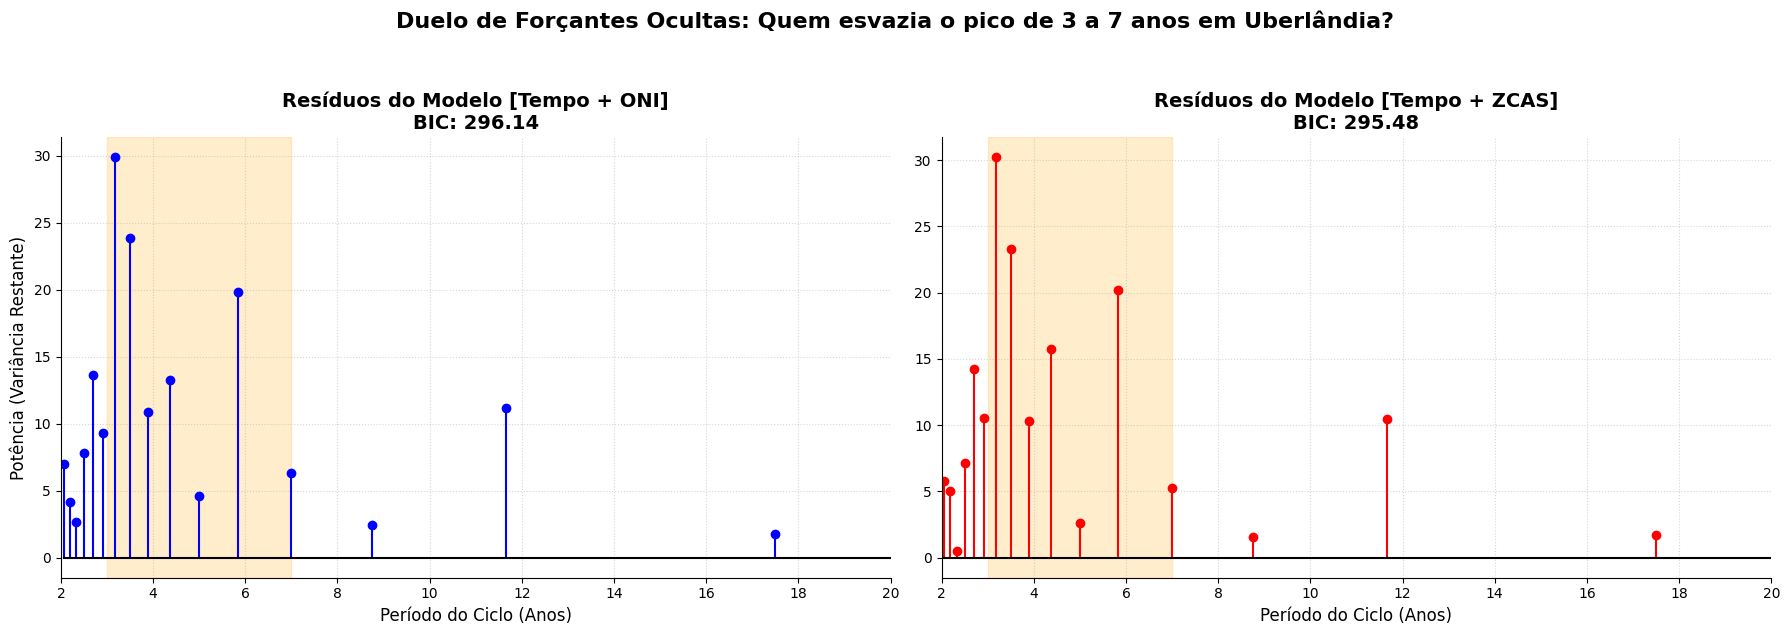

In [ ]:
# ==============================================================================
# CÉLULA 47 (CORRIGIDA): A PROVA FINAL DOS RESÍDUOS (UBERLÂNDIA)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import genextreme
from scipy.signal import periodogram
import warnings
warnings.filterwarnings('ignore')

print("1. O Grande Intersect: Alinhando rigorosamente os vetores...")

# Pega os anos brutos do pixel
anos_raw = pixel_uber['ano'].dropna(dim='ano').values
df_chuva_uber = pixel_uber['pr'].to_dataframe().reset_index().dropna()

# 1.1 Descobre os anos em que TEMOS OS TRÊS DADOS (Chuva, ONI e ZCAS)
anos_comuns = set(anos_raw).intersection(set(df_oni_base['ano'])).intersection(set(df_zcas_base['ano']))
anos_comuns = np.sort(list(anos_comuns))

print(f" -> Encontramos {len(anos_comuns)} anos simultâneos perfeitamente alinhados.")

# 1.2 Filtra todas as variáveis para terem o exato mesmo tamanho
y_uber = df_chuva_uber[df_chuva_uber['ano'].isin(anos_comuns)].sort_values('ano')['pr'].values
x_oni_uber = df_oni_base[df_oni_base['ano'].isin(anos_comuns)].sort_values('ano')['ONI_Verao'].values
x_zcas_uber = df_zcas_base[df_zcas_base['ano'].isin(anos_comuns)].sort_values('ano')['dias_ativos_zcas'].values

# O vetor de tempo agora acompanha o tamanho da amostra comum
t_uber = np.arange(1, len(y_uber) + 1)
n = len(y_uber)

print("2. Otimizando os Modelos Aditivos (Tempo + Forçante)...")

# Função genérica para modelo aditivo (Tempo + Covariável X)
def ajustar_modelo_aditivo(y, t, x_cov):
    def nll(p):
        mu0, mu_t, mu_x, sigma, xi = p
        if sigma <= 0: return 1e10
        mu_t_array = mu0 + mu_t * t + mu_x * x_cov
        try:
            ll = np.sum(genextreme.logpdf(y, -xi, loc=mu_t_array, scale=sigma))
            return -ll if np.isfinite(ll) else 1e10
        except: return 1e10

    # Chute inicial ancorado na média
    chute = [np.mean(y), 0.0, 0.0, np.std(y), 0.1]
    res = minimize(nll, chute, method='Nelder-Mead', options={'maxiter': 5000})

    if res.success:
        bic = 5 * np.log(len(y)) + 2 * res.fun
        # Retorna BIC, os parâmetros e a série do mu calculado
        mu_calculado = res.x[0] + res.x[1] * t + res.x[2] * x_cov
        return bic, res.x, mu_calculado
    return np.inf, None, None

# Roda os dois modelos
bic_toni, params_toni, mu_toni = ajustar_modelo_aditivo(y_uber, t_uber, x_oni_uber)
bic_tzcas, params_tzcas, mu_tzcas = ajustar_modelo_aditivo(y_uber, t_uber, x_zcas_uber)

print("\n🏆 TRIBUNAL ADITIVO (TEMPO + FORÇANTE):")
print(f" -> BIC [Tempo + ONI] : {bic_toni:.2f}")
print(f" -> BIC [Tempo + ZCAS]: {bic_tzcas:.2f}")

if bic_toni < bic_tzcas:
    print("\n -> O BIC cravou: O El Niño (ONI) é o verdadeiro parceiro da tendência temporal aqui!")
else:
    print("\n -> O BIC cravou: A ZCAS é a verdadeira parceira da tendência temporal aqui!")

# --- CÁLCULO DOS RESÍDUOS ---
residuos_toni = y_uber - mu_toni
f_toni, p_toni = periodogram(residuos_toni, fs=1.0, scaling='spectrum')

residuos_tzcas = y_uber - mu_tzcas
f_tzcas, p_tzcas = periodogram(residuos_tzcas, fs=1.0, scaling='spectrum')

print("\n3. Desenhando os Espectros de Frequência...")

# ------------------------------------------------------------------------------
# PLOTAGEM DUPLA (PERIODOGRAMAS DE RESÍDUOS)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- GRÁFICO 1: RESÍDUOS TEMPO + ONI ---
ax1.stem(1/f_toni[1:], p_toni[1:], linefmt='b-', markerfmt='bo', basefmt='k-')
ax1.axvspan(3, 7, color='orange', alpha=0.2, label='Banda de Variabilidade (3 a 7 anos)')
ax1.set_title(f"Resíduos do Modelo [Tempo + ONI]\nBIC: {bic_toni:.2f}", fontsize=14, fontweight='bold')
ax1.set_xlabel("Período do Ciclo (Anos)", fontsize=12)
ax1.set_ylabel("Potência (Variância Restante)", fontsize=12)
ax1.set_xlim(2, 20)
ax1.set_xticks(np.arange(2, 21, 2))
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- GRÁFICO 2: RESÍDUOS TEMPO + ZCAS ---
ax2.stem(1/f_tzcas[1:], p_tzcas[1:], linefmt='r-', markerfmt='ro', basefmt='k-')
ax2.axvspan(3, 7, color='orange', alpha=0.2, label='Banda de Variabilidade (3 a 7 anos)')
ax2.set_title(f"Resíduos do Modelo [Tempo + ZCAS]\nBIC: {bic_tzcas:.2f}", fontsize=14, fontweight='bold')
ax2.set_xlabel("Período do Ciclo (Anos)", fontsize=12)
ax2.set_xlim(2, 20)
ax2.set_xticks(np.arange(2, 21, 2))
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle("Duelo de Forçantes Ocultas: Quem esvazia o pico de 3 a 7 anos em Uberlândia?", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()